# ESM-C SAE Layer Ensemble Analysis

This notebook investigates ways to combine multiple fixed DeltaEmbSAE model/layer outputs for BRCA1 while excluding ESM2 entirely. It reuses the artifacts produced by `lower_context.ipynb`, including the layer-level Spearman/AUC table, fixed SAE reconstruction table, and per-layer fitness CSVs.

Analyses covered here:

- Rank ensembles over ESM-C SAE layers using median, best, and worst rank.
- Collections: all ESM-C SAE layers, top AUC, top MaveDB Spearman, top SAE reconstruction R2, and a balanced AUC/Spearman/reconstruction subset.
- PCA-concatenated SAE inference: per selected SAE, fit PCA to SAE activations, keep the globally most important PCs up to `PCA_MAX_COMPONENTS`, concatenate those coordinates, run popDMS inference, and save the gamma consistency plot.

I interpret "MaveDB reconstruction" as the SAE reconstruction R2 computed on the MaveDB variant feature table, and also include a top MaveDB-Spearman collection so both readings are available.

In [1]:
from pathlib import Path
import os
import pickle
import subprocess
import sys
import importlib

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "esmDMS.py").exists():
    for parent in Path.cwd().parents:
        if (parent / "esmDMS.py").exists():
            REPO_ROOT = parent
            break
sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, Markdown, display

import lower_context_helpers as h
h = importlib.reload(h)

sns.set_theme(style="darkgrid")
paths = h.default_brca1_paths(REPO_ROOT)
paths

BRCA1Paths(repo_root=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS'), data_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/mavedb_data'), analysis_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae'), baseline_analysis_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_experimental'), sequence_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data'), figure_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures'), table_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables'), job_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs'), baseline_table_dir=PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_experimental/tables'),

## Configuration

`SUBMIT_JOB` is `False` by default, so running this notebook writes the payload and Slurm script without submitting. Set it to `True` after reviewing `tasks_df`. PCA jobs are the expensive part; the rank ensembles are lightweight but are included in the same array for reproducibility.

In [2]:
DATASET_NAME = "BRCA1"
EMBEDDING_TYPE = "max_pool"
FIGURE_DPI = 450

OUTPUT_ROOT = paths.analysis_dir / "esmc_sae_layer_ensemble_analysis"
JOB_ROOT = paths.job_dir / "esmc_sae_layer_ensemble_analysis"
for directory in [OUTPUT_ROOT, JOB_ROOT, OUTPUT_ROOT / "metrics", OUTPUT_ROOT / "fitness", OUTPUT_ROOT / "figures"]:
    directory.mkdir(parents=True, exist_ok=True)

COLLECTION_TOP_N = 12
BALANCED_PER_MODEL = 4
RANK_AGGREGATIONS = ["rank_median", "rank_worst", "rank_best"]

PCA_MAX_COMPONENTS = 1000
PCA_PER_SOURCE_COMPONENTS = 64
PCA_STANDARDIZE_INPUTS = True
PCA_IMPORTANCE_METRIC = "explained_variance_ratio"
PCA_RANDOM_SEED = 42

CREATE_JOB = True
SUBMIT_JOB = False
CREATE_MAVEDB_GAMMA_JOB = True
SUBMIT_MAVEDB_GAMMA_JOB = False
MAX_ACTIVE_TASKS = 4
PYTHON_EXECUTABLE = "python3"
SLURM_PARTITION = "any_cpu"
SLURM_CPUS_PER_TASK = 4
SLURM_MEM = "48G"
SLURM_TIME = "12:00:00"

RUN_LOCAL_SMOKE_TASK = False
LOCAL_SMOKE_TASK_IDX = 0

print(f"Output root: {OUTPUT_ROOT}")
print(f"Gamma diagnostics plots will be under: {OUTPUT_ROOT / 'pca_concat'}")


Output root: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis
Gamma diagnostics plots will be under: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat


## Load Existing Tables And Build ESM-C Collections

The helper filters source rows to `biohub/ESMC-*` / `ESMC-*` rows only and excludes layer 0. If ESM-C 6B artifacts are added later, they will be included automatically once they appear in the metrics tables.

In [3]:
runner = h.processed_brca1_runner(paths, model_name="biohub/ESMC-300M", dataset_name=DATASET_NAME, embedding_type=EMBEDDING_TYPE)
metrics_df = h.load_metrics_table(paths.spearman_auc_table_path)
sae_metrics_df = pd.read_csv(paths.fixed_sae_metrics_path) if paths.fixed_sae_metrics_path.is_file() else pd.DataFrame()

collections = h.build_esmc_sae_collections(
    metrics_df,
    sae_metrics_df,
    embedding_type=EMBEDDING_TYPE,
    top_n=COLLECTION_TOP_N,
    balanced_per_model=BALANCED_PER_MODEL,
)
assert collections, "No ESM-C SAE collections were found. Run/collect lower_context.ipynb first."
assert all(h.is_esmc_row(rows).all() for rows in collections.values()), "A non-ESM-C row leaked into an ESM-C collection."

collection_summary = pd.DataFrame([
    {
        "collection_name": name,
        "n_layers": len(rows),
        "models": ", ".join(sorted(rows["model_short"].dropna().astype(str).unique())),
        "layer_min": int(rows["layer"].min()) if len(rows) else np.nan,
        "layer_max": int(rows["layer"].max()) if len(rows) else np.nan,
        "mean_auc": rows["auc"].mean(),
        "mean_spearman": rows["spearman_rho"].mean(),
        "mean_reconstruction_r2": rows.get("reconstruction_r2", pd.Series(dtype=float)).mean(),
    }
    for name, rows in collections.items()
])
collection_summary.to_csv(OUTPUT_ROOT / "esmc_sae_collection_summary.csv", index=False)
display(collection_summary)

,collection_name,n_layers,models,layer_min,layer_max,mean_auc,mean_spearman,mean_reconstruction_r2
0,all_esmc_sae_layers,66,"ESMC-300M, ESMC-600M",1,36,0.912153,0.340884,0.747386
1,best_auc_top12,12,"ESMC-300M, ESMC-600M",5,36,0.939883,0.394799,0.562070
2,best_mavedb_spearman_top12,12,"ESMC-300M, ESMC-600M",13,36,0.936758,0.403797,0.561403
3,best_reconstruction_r2_top12,12,"ESMC-300M, ESMC-600M",5,19,0.910906,0.322089,0.950957
4,balanced_auc_spearman_reconstruction_top4_per_...,8,"ESMC-300M, ESMC-600M",15,35,0.930434,0.393690,0.791269


In [4]:
preview_rows = []
for name, rows in collections.items():
    preview = rows.sort_values(["auc", "spearman_rho"], ascending=[False, False]).head(8).copy()
    preview.insert(0, "collection_name", name)
    preview_rows.append(preview)
collection_preview_df = pd.concat(preview_rows, ignore_index=True, sort=False)
display(
    collection_preview_df[
        ["collection_name", "model_short", "layer", "auc", "spearman_rho", "reconstruction_r2", "feature_path", "fitness_path"]
    ].assign(
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        reconstruction_r2=lambda df: pd.to_numeric(df["reconstruction_r2"], errors="coerce").round(3),
    )
)

,collection_name,model_short,layer,auc,spearman_rho,reconstruction_r2,feature_path,fitness_path
0,all_esmc_sae_layers,ESMC-600M,36.0,0.961,0.449,-0.319,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,all_esmc_sae_layers,ESMC-300M,30.0,0.952,0.439,-0.633,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,all_esmc_sae_layers,ESMC-300M,29.0,0.947,0.415,0.708,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,all_esmc_sae_layers,ESMC-600M,32.0,0.943,0.421,0.717,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,all_esmc_sae_layers,ESMC-600M,30.0,0.936,0.389,0.757,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
5,all_esmc_sae_layers,ESMC-600M,6.0,0.936,0.333,0.865,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
6,all_esmc_sae_layers,ESMC-600M,5.0,0.936,0.340,0.857,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
7,all_esmc_sae_layers,ESMC-600M,34.0,0.936,0.424,0.686,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
8,best_auc_top12,ESMC-600M,36.0,0.961,0.449,-0.319,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
9,best_auc_top12,ESMC-300M,30.0,0.952,0.439,-0.633,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Build Slurm Tasks

Rank tasks cover every collection and each requested rank aggregation. PCA-concat tasks run once per collection and save the cross-replicate gamma consistency plot for that inferred concatenated feature space.

In [5]:
def _pretty_collection_label(name):
    return name.replace("_", " ").replace("top", "top ")

rank_collections = list(collections)
pca_collections = [
    "all_esmc_sae_layers",
    f"best_auc_top{COLLECTION_TOP_N}",
    f"best_mavedb_spearman_top{COLLECTION_TOP_N}",
    f"best_reconstruction_r2_top{COLLECTION_TOP_N}",
    f"balanced_auc_spearman_reconstruction_top{BALANCED_PER_MODEL}_per_model",
]
pca_collections = [name for name in pca_collections if name in collections]

tasks = []
for collection_name in rank_collections:
    for aggregation in RANK_AGGREGATIONS:
        label = f"{_pretty_collection_label(collection_name)} {aggregation.replace('rank_', '')} rank"
        tasks.append({
            "task_type": "rank_ensemble",
            "collection_name": collection_name,
            "aggregation": aggregation,
            "method_label": label,
            "short_label": label.replace("all esmc sae layers", "all ESMC"),
        })

crossrep_pca_tasks = []
for collection_name in pca_collections:
    label = f"{_pretty_collection_label(collection_name)} PCA concat"
    crossrep_pca_tasks.append({
        "task_type": "pca_concat",
        "collection_name": collection_name,
        "method_label": f"{label} (consistency gamma)",
        "short_label": f"{label.replace('all esmc sae layers', 'all ESMC')} consistency gamma",
        "max_components": PCA_MAX_COMPONENTS,
        "per_source_components": PCA_PER_SOURCE_COMPONENTS,
        "standardize": PCA_STANDARDIZE_INPUTS,
        "importance_metric": PCA_IMPORTANCE_METRIC,
        "seed": PCA_RANDOM_SEED,
        "gamma_selection_objective": "cross_replicate_consistency",
    })
tasks.extend(crossrep_pca_tasks)

mavedb_gamma_tasks = []
for collection_name in pca_collections:
    label = f"{_pretty_collection_label(collection_name)} PCA concat"
    mavedb_gamma_tasks.append({
        "task_type": "pca_concat",
        "collection_name": collection_name,
        "method_label": f"{label} (MaveDB gamma)",
        "short_label": f"{label.replace('all esmc sae layers', 'all ESMC')} MaveDB gamma",
        "max_components": PCA_MAX_COMPONENTS,
        "per_source_components": PCA_PER_SOURCE_COMPONENTS,
        "standardize": PCA_STANDARDIZE_INPUTS,
        "importance_metric": PCA_IMPORTANCE_METRIC,
        "seed": PCA_RANDOM_SEED,
        "gamma_selection_objective": "mavedb_spearman",
    })

tasks_df = pd.DataFrame(tasks)
tasks_df.insert(0, "task_idx", range(len(tasks_df)))
tasks_df["n_source_layers"] = tasks_df["collection_name"].map(lambda name: len(collections[name]))
tasks_df.to_csv(OUTPUT_ROOT / "esmc_sae_ensemble_tasks.csv", index=False)

mavedb_gamma_tasks_df = pd.DataFrame(mavedb_gamma_tasks)
mavedb_gamma_tasks_df.insert(0, "task_idx", range(len(mavedb_gamma_tasks_df)))
mavedb_gamma_tasks_df["n_source_layers"] = mavedb_gamma_tasks_df["collection_name"].map(lambda name: len(collections[name]))
mavedb_gamma_tasks_df.to_csv(OUTPUT_ROOT / "esmc_sae_ensemble_mavedb_gamma_tasks.csv", index=False)

display(tasks_df)
display(mavedb_gamma_tasks_df)


,task_idx,task_type,collection_name,aggregation,method_label,short_label,max_components,per_source_components,standardize,importance_metric,seed,gamma_selection_objective,n_source_layers
0,0,rank_ensemble,all_esmc_sae_layers,rank_median,all esmc sae layers median rank,all ESMC median rank,NaN,NaN,NaN,NaN,NaN,NaN,66
1,1,rank_ensemble,all_esmc_sae_layers,rank_worst,all esmc sae layers worst rank,all ESMC worst rank,NaN,NaN,NaN,NaN,NaN,NaN,66
2,2,rank_ensemble,all_esmc_sae_layers,rank_best,all esmc sae layers best rank,all ESMC best rank,NaN,NaN,NaN,NaN,NaN,NaN,66
3,3,rank_ensemble,best_auc_top12,rank_median,best auc top 12 median rank,best auc top 12 median rank,NaN,NaN,NaN,NaN,NaN,NaN,12
4,4,rank_ensemble,best_auc_top12,rank_worst,best auc top 12 worst rank,best auc top 12 worst rank,NaN,NaN,NaN,NaN,NaN,NaN,12
5,5,rank_ensemble,best_auc_top12,rank_best,best auc top 12 best rank,best auc top 12 best rank,NaN,NaN,NaN,NaN,NaN,NaN,12
6,6,rank_ensemble,best_mavedb_spearman_top12,rank_median,best mavedb spearman top 12 median rank,best mavedb spearman top 12 median rank,NaN,NaN,NaN,NaN,NaN,NaN,12
7,7,rank_ensemble,best_mavedb_spearman_top12,rank_worst,best mavedb spearman top 12 worst rank,best mavedb spearman top 12 worst rank,NaN,NaN,NaN,NaN,NaN,NaN,12
8,8,rank_ensemble,best_mavedb_spearman_top12,rank_best,best mavedb spearman top 12 best rank,best mavedb spearman top 12 best rank,NaN,NaN,NaN,NaN,NaN,NaN,12
9,9,rank_ensemble,best_reconstruction_r2_top12,rank_median,best reconstruction r2 top 12 median rank,best reconstruction r2 top 12 median rank,NaN,NaN,NaN,NaN,NaN,NaN,12


,task_idx,task_type,collection_name,method_label,short_label,max_components,per_source_components,standardize,importance_metric,seed,gamma_selection_objective,n_source_layers
0,0,pca_concat,all_esmc_sae_layers,all esmc sae layers PCA concat (MaveDB gamma),all ESMC PCA concat MaveDB gamma,1000,64,True,explained_variance_ratio,42,mavedb_spearman,66
1,1,pca_concat,best_auc_top12,best auc top 12 PCA concat (MaveDB gamma),best auc top 12 PCA concat MaveDB gamma,1000,64,True,explained_variance_ratio,42,mavedb_spearman,12
2,2,pca_concat,best_mavedb_spearman_top12,best mavedb spearman top 12 PCA concat (MaveDB...,best mavedb spearman top 12 PCA concat MaveDB ...,1000,64,True,explained_variance_ratio,42,mavedb_spearman,12
3,3,pca_concat,best_reconstruction_r2_top12,best reconstruction r2 top 12 PCA concat (Mave...,best reconstruction r2 top 12 PCA concat MaveD...,1000,64,True,explained_variance_ratio,42,mavedb_spearman,12
4,4,pca_concat,balanced_auc_spearman_reconstruction_top4_per_...,balanced auc spearman reconstruction top 4 per...,balanced auc spearman reconstruction top 4 per...,1000,64,True,explained_variance_ratio,42,mavedb_spearman,8


## Write Payload And Slurm Script

The generated worker writes one status JSON per task under `OUTPUT_ROOT/status`. Full task outputs land in `OUTPUT_ROOT/metrics`, `OUTPUT_ROOT/fitness`, and `OUTPUT_ROOT/pca_concat`.

In [6]:
payload = {
    "repo_root": str(REPO_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "dataset_name": DATASET_NAME,
    "embedding_type": EMBEDDING_TYPE,
    "metrics_path": str(paths.spearman_auc_table_path),
    "sae_metrics_path": str(paths.fixed_sae_metrics_path),
    "clinvar_annotation_cache_path": str(paths.clinvar_annotation_cache_path),
    "primary_key": "hgvs_nt",
    "score_col": "score",
    "collection_top_n": COLLECTION_TOP_N,
    "balanced_per_model": BALANCED_PER_MODEL,
    "max_components": PCA_MAX_COMPONENTS,
    "per_source_components": PCA_PER_SOURCE_COMPONENTS,
    "standardize_pca_inputs": PCA_STANDARDIZE_INPUTS,
    "importance_metric": PCA_IMPORTANCE_METRIC,
    "seed": PCA_RANDOM_SEED,
    "tasks": tasks,
}

payload_path = JOB_ROOT / "esmc_sae_layer_ensemble_payload.pkl"
script_path = JOB_ROOT / "submit_esmc_sae_layer_ensemble_array.sh"
log_dir = JOB_ROOT / "logs"

if CREATE_JOB:
    with payload_path.open("wb") as handle:
        pickle.dump(payload, handle)
    h.write_slurm_array_job(
        script_path=script_path,
        payload_path=payload_path,
        runner_script=REPO_ROOT / "job_scripts" / "run_esmc_sae_ensemble_task.py",
        n_tasks=len(tasks),
        job_name="brca1_esmc_sae_ens",
        repo_root=REPO_ROOT,
        log_dir=log_dir,
        partition=SLURM_PARTITION,
        cpus_per_task=SLURM_CPUS_PER_TASK,
        mem=SLURM_MEM,
        time=SLURM_TIME,
        max_active_tasks=MAX_ACTIVE_TASKS,
        python_executable=PYTHON_EXECUTABLE,
    )
    print(f"Cross-replicate payload: {payload_path}")
    print(f"Cross-replicate Slurm script: {script_path}")
    if SUBMIT_JOB:
        completed = subprocess.run(["sbatch", str(script_path)], check=True, capture_output=True, text=True)
        print(completed.stdout.strip())

mavedb_gamma_payload = dict(payload)
mavedb_gamma_payload["tasks"] = mavedb_gamma_tasks
mavedb_gamma_payload["gamma_selection_objective"] = "mavedb_spearman"
mavedb_gamma_payload_path = JOB_ROOT / "esmc_sae_layer_ensemble_mavedb_gamma_payload.pkl"
mavedb_gamma_script_path = JOB_ROOT / "submit_esmc_sae_layer_ensemble_mavedb_gamma_array.sh"

if CREATE_MAVEDB_GAMMA_JOB:
    with mavedb_gamma_payload_path.open("wb") as handle:
        pickle.dump(mavedb_gamma_payload, handle)
    h.write_slurm_array_job(
        script_path=mavedb_gamma_script_path,
        payload_path=mavedb_gamma_payload_path,
        runner_script=REPO_ROOT / "job_scripts" / "run_esmc_sae_ensemble_task.py",
        n_tasks=len(mavedb_gamma_tasks),
        job_name="brca1_esmc_sae_mvg",
        repo_root=REPO_ROOT,
        log_dir=JOB_ROOT / "logs_mavedb_gamma",
        partition=SLURM_PARTITION,
        cpus_per_task=SLURM_CPUS_PER_TASK,
        mem=SLURM_MEM,
        time=SLURM_TIME,
        max_active_tasks=MAX_ACTIVE_TASKS,
        python_executable=PYTHON_EXECUTABLE,
    )
    print(f"MaveDB-gamma payload: {mavedb_gamma_payload_path}")
    print(f"MaveDB-gamma Slurm script: {mavedb_gamma_script_path}")
    if SUBMIT_MAVEDB_GAMMA_JOB:
        completed = subprocess.run(["sbatch", str(mavedb_gamma_script_path)], check=True, capture_output=True, text=True)
        print(completed.stdout.strip())


Cross-replicate payload: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/esmc_sae_layer_ensemble_payload.pkl
Cross-replicate Slurm script: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/submit_esmc_sae_layer_ensemble_array.sh
MaveDB-gamma payload: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/esmc_sae_layer_ensemble_mavedb_gamma_payload.pkl
MaveDB-gamma Slurm script: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/submit_esmc_sae_layer_ensemble_mavedb_gamma_array.sh


In [7]:
if RUN_LOCAL_SMOKE_TASK:
    completed = subprocess.run(
        [PYTHON_EXECUTABLE, str(REPO_ROOT / "job_scripts" / "run_esmc_sae_ensemble_task.py"), str(payload_path), str(LOCAL_SMOKE_TASK_IDX)],
        check=True,
        capture_output=True,
        text=True,
    )
    print(completed.stdout)

## Collect Finished Task Outputs

Run this section after the Slurm array has finished. It combines every per-task metrics table and writes a single review-star metrics table for downstream plotting.

In [8]:
metrics_files = sorted((OUTPUT_ROOT / "metrics").glob("*_metrics_by_review_stars.csv"))
print(f"Found {len(metrics_files)} metrics file(s).")
if metrics_files:
    esmc_ensemble_metrics_df = pd.concat([pd.read_csv(path) for path in metrics_files], ignore_index=True, sort=False)
    for column in ["gamma_opt", "gamma_plot_path", "gamma_table_path", "gamma_pair_table_path", "gamma_selection_objective", "selected_gamma_mean_pairwise_pearson_r", "selected_gamma_mavedb_spearman", "selected_gamma_grid", "n_selected_components"]:
        if column not in esmc_ensemble_metrics_df.columns:
            esmc_ensemble_metrics_df[column] = np.nan
    def _normalize_gamma_objective(row):
        value = row.get("gamma_selection_objective", "")
        is_blank = pd.isna(value) or str(value).strip() == ""
        if row.get("aggregation") == "pca_concat" and is_blank:
            return "cross_replicate_consistency"
        if is_blank:
            return "not_applicable"
        return value

    esmc_ensemble_metrics_df["gamma_selection_objective"] = esmc_ensemble_metrics_df.apply(_normalize_gamma_objective, axis=1)

    def _gamma_objective_label(row):
        label = str(row["method_label"])
        if row.get("aggregation") != "pca_concat":
            return label
        objective = row.get("gamma_selection_objective")
        if objective == "cross_replicate_consistency" and "gamma" not in label.lower():
            return f"{label} (consistency gamma)"
        if objective == "mavedb_spearman" and "mavedb" not in label.lower():
            return f"{label} (MaveDB gamma)"
        return label

    esmc_ensemble_metrics_df["method_label"] = esmc_ensemble_metrics_df.apply(_gamma_objective_label, axis=1)
    if "short_label" in esmc_ensemble_metrics_df.columns:
        esmc_ensemble_metrics_df["short_label"] = esmc_ensemble_metrics_df.apply(
            lambda row: row["method_label"] if row.get("aggregation") == "pca_concat" else row.get("short_label", row["method_label"]),
            axis=1,
        )
    combined_metrics_path = paths.table_dir / "BRCA1_esmc_sae_layer_ensemble_metrics_by_review_stars.csv"
    esmc_ensemble_metrics_df.to_csv(combined_metrics_path, index=False)
    display(
        esmc_ensemble_metrics_df[
            ["review_filter", "method_label", "aggregation", "model_filter", "gamma_selection_objective", "n_component_model_layers", "spearman_rho", "auc", "functional_score_auc", "gamma_opt", "selected_gamma_mean_pairwise_pearson_r", "selected_gamma_mavedb_spearman", "gamma_plot_path"]
        ].assign(
            spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
            auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
            functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
            selected_gamma_mean_pairwise_pearson_r=lambda df: pd.to_numeric(df["selected_gamma_mean_pairwise_pearson_r"], errors="coerce").round(3),
            selected_gamma_mavedb_spearman=lambda df: pd.to_numeric(df["selected_gamma_mavedb_spearman"], errors="coerce").round(3),
        )
    )
else:
    esmc_ensemble_metrics_df = pd.DataFrame()
    combined_metrics_path = None


Found 25 metrics file(s).


,review_filter,method_label,aggregation,model_filter,gamma_selection_objective,n_component_model_layers,spearman_rho,auc,functional_score_auc,gamma_opt,selected_gamma_mean_pairwise_pearson_r,selected_gamma_mavedb_spearman,gamma_plot_path
0,all binary annotations,all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,0.931,0.989,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,>= 1 star(s),all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,0.939,0.991,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,>= 2 star(s),all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,0.962,0.991,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,>= 3 star(s),all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,0.978,0.982,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,>= 4 star(s),all esmc sae layers PCA concat (MaveDB gamma),pca_concat,all_esmc_sae_layers,mavedb_spearman,66,0.413,NaN,NaN,0.01,0.758,0.413,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,all binary annotations,best reconstruction r2 top 12 worst rank,rank_worst,best_reconstruction_r2_top12,not_applicable,12,0.350,0.944,0.989,NaN,NaN,NaN,NaN
121,>= 1 star(s),best reconstruction r2 top 12 worst rank,rank_worst,best_reconstruction_r2_top12,not_applicable,12,0.350,0.947,0.991,NaN,NaN,NaN,NaN
122,>= 2 star(s),best reconstruction r2 top 12 worst rank,rank_worst,best_reconstruction_r2_top12,not_applicable,12,0.350,0.978,0.991,NaN,NaN,NaN,NaN
123,>= 3 star(s),best reconstruction r2 top 12 worst rank,rank_worst,best_reconstruction_r2_top12,not_applicable,12,0.350,0.978,0.982,NaN,NaN,NaN,NaN


## Performance Summary

This table collapses the review-star rows into one row per method/objective and keeps the all-binary MaveDB Spearman plus AUC at all, 1, 2, and 3-star filters.


In [9]:
if not esmc_ensemble_metrics_df.empty:
    performance_summary_df = h.performance_summary_table(esmc_ensemble_metrics_df)
    performance_summary_path = paths.table_dir / "BRCA1_esmc_sae_layer_ensemble_performance_summary.csv"
    performance_summary_df.to_csv(performance_summary_path, index=False)
    display_columns = [
        "spearman_auc_rank",
        "spearman_auc_rank_score",
        "mavedb_spearman_rank",
        "auc_all_binary_rank",
        "method_label",
        "aggregation",
        "model_filter",
        "gamma_selection_objective",
        "n_component_model_layers",
        "n_selected_components",
        "gamma_opt",
        "selected_gamma_mean_pairwise_pearson_r",
        "selected_gamma_mavedb_spearman",
        "mavedb_spearman",
        "auc_all_binary",
        "auc_min_1_stars",
        "auc_min_2_stars",
        "auc_min_3_stars",
    ]
    display(
        performance_summary_df[[col for col in display_columns if col in performance_summary_df.columns]].assign(
            spearman_auc_rank_score=lambda df: pd.to_numeric(df.get("spearman_auc_rank_score", np.nan), errors="coerce").round(2),
            mavedb_spearman_rank=lambda df: pd.to_numeric(df.get("mavedb_spearman_rank", np.nan), errors="coerce").astype("Int64"),
            auc_all_binary_rank=lambda df: pd.to_numeric(df.get("auc_all_binary_rank", np.nan), errors="coerce").astype("Int64"),
            gamma_opt=lambda df: pd.to_numeric(df.get("gamma_opt", np.nan), errors="coerce"),
            selected_gamma_mean_pairwise_pearson_r=lambda df: pd.to_numeric(df.get("selected_gamma_mean_pairwise_pearson_r", np.nan), errors="coerce").round(3),
            selected_gamma_mavedb_spearman=lambda df: pd.to_numeric(df.get("selected_gamma_mavedb_spearman", np.nan), errors="coerce").round(3),
            mavedb_spearman=lambda df: pd.to_numeric(df.get("mavedb_spearman", np.nan), errors="coerce").round(3),
            auc_all_binary=lambda df: pd.to_numeric(df.get("auc_all_binary", np.nan), errors="coerce").round(3),
            auc_min_1_stars=lambda df: pd.to_numeric(df.get("auc_min_1_stars", np.nan), errors="coerce").round(3),
            auc_min_2_stars=lambda df: pd.to_numeric(df.get("auc_min_2_stars", np.nan), errors="coerce").round(3),
            auc_min_3_stars=lambda df: pd.to_numeric(df.get("auc_min_3_stars", np.nan), errors="coerce").round(3),
        )
    )
    print(f"Performance summary ranked by combined MaveDB-Spearman/AUC: {performance_summary_path}")
else:
    performance_summary_df = pd.DataFrame()


,spearman_auc_rank,spearman_auc_rank_score,mavedb_spearman_rank,auc_all_binary_rank,method_label,aggregation,model_filter,gamma_selection_objective,n_component_model_layers,n_selected_components,gamma_opt,selected_gamma_mean_pairwise_pearson_r,selected_gamma_mavedb_spearman,mavedb_spearman,auc_all_binary,auc_min_1_stars,auc_min_2_stars,auc_min_3_stars
0,1,1.5,1,2,best mavedb spearman top 12 worst rank,rank_worst,best_mavedb_spearman_top12,not_applicable,12,NaN,NaN,NaN,NaN,0.449,0.966,0.974,0.991,0.992
1,1,1.5,2,1,best auc top 12 worst rank,rank_worst,best_auc_top12,not_applicable,12,NaN,NaN,NaN,NaN,0.439,0.970,0.973,0.991,0.992
2,3,4.0,3,5,best auc top 12 median rank,rank_median,best_auc_top12,not_applicable,12,NaN,NaN,NaN,NaN,0.432,0.951,0.959,0.978,0.988
3,3,4.0,4,4,balanced auc spearman reconstruction top 4 per...,rank_worst,balanced_auc_spearman_reconstruction_top4_per_...,not_applicable,8,NaN,NaN,NaN,NaN,0.432,0.956,0.964,0.980,0.989
4,5,6.0,6,6,best mavedb spearman top 12 median rank,rank_median,best_mavedb_spearman_top12,not_applicable,12,NaN,NaN,NaN,NaN,0.427,0.945,0.952,0.967,0.989
5,6,6.5,5,8,best mavedb spearman top 12 PCA concat (MaveDB...,pca_concat,best_mavedb_spearman_top12,mavedb_spearman,12,768.0,0.010000,0.787,0.431,0.431,0.938,0.946,0.964,0.968
6,7,7.0,11,3,all esmc sae layers worst rank,rank_worst,all_esmc_sae_layers,not_applicable,66,NaN,NaN,NaN,NaN,0.391,0.958,0.959,0.984,0.987
7,8,8.5,7,10,best mavedb spearman top 12 PCA concat (consis...,pca_concat,best_mavedb_spearman_top12,cross_replicate_consistency,12,768.0,0.183298,NaN,NaN,0.419,0.934,0.942,0.956,0.967
8,9,9.0,9,9,balanced auc spearman reconstruction top 4 per...,rank_median,balanced_auc_spearman_reconstruction_top4_per_...,not_applicable,8,NaN,NaN,NaN,NaN,0.417,0.937,0.944,0.959,0.990
9,10,10.0,8,12,best auc top 12 PCA concat (MaveDB gamma),pca_concat,best_auc_top12,mavedb_spearman,12,768.0,0.020691,0.757,0.418,0.418,0.932,0.939,0.958,0.944


Performance summary ranked by combined MaveDB-Spearman/AUC: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_esmc_sae_layer_ensemble_performance_summary.csv


## Gamma Objective Comparison

After the MaveDB-gamma jobs finish, this compares the selected-gamma replicate consistency, all-binary MaveDB Spearman, and all-binary ClinVar AUC against the cross-replicate gamma jobs for the same PCA collection.


In [10]:
if not performance_summary_df.empty:
    gamma_objective_comparison_df = h.gamma_objective_comparison_table(performance_summary_df)
    gamma_objective_comparison_path = paths.table_dir / "BRCA1_esmc_sae_layer_ensemble_gamma_objective_comparison.csv"
    gamma_objective_comparison_df.to_csv(gamma_objective_comparison_path, index=False)
    display(gamma_objective_comparison_df)
    gamma_objective_comparison_figure_path = paths.figure_dir / "BRCA1_esmc_sae_layer_ensemble_gamma_objective_comparison.png"
    print(f"Gamma objective comparison table: {gamma_objective_comparison_path}")
else:
    gamma_objective_comparison_df = pd.DataFrame()


,model_filter,crossrep_method_label,crossrep_gamma_opt,crossrep_selected_gamma_mean_pairwise_pearson_r,crossrep_selected_gamma_mavedb_spearman,crossrep_mavedb_spearman,crossrep_auc_all_binary,crossrep_auc_min_1_stars,crossrep_auc_min_2_stars,crossrep_auc_min_3_stars,...,mavedb_gamma_auc_all_binary,mavedb_gamma_auc_min_1_stars,mavedb_gamma_auc_min_2_stars,mavedb_gamma_auc_min_3_stars,delta_gamma_opt,delta_mavedb_spearman,delta_auc_all_binary,delta_auc_min_1_stars,delta_auc_min_2_stars,delta_auc_min_3_stars
0,all_esmc_sae_layers,all esmc sae layers PCA concat (consistency ga...,3.359818,NaN,NaN,0.335322,0.911046,0.917829,0.930646,0.928911,...,0.931410,0.938957,0.961633,0.978223,-3.349818,0.078043,0.020364,0.021128,0.030987,0.049312
1,balanced_auc_spearman_reconstruction_top4_per_...,balanced auc spearman reconstruction top 4 per...,127.427499,NaN,NaN,0.307155,0.862651,0.867548,0.898792,0.916646,...,0.912010,0.919380,0.945326,0.963705,-127.384685,0.072799,0.049360,0.051832,0.046534,0.047059
2,best_auc_top12,best auc top 12 PCA concat (consistency gamma),1.623777,NaN,NaN,0.371336,0.920100,0.927377,0.948503,0.944681,...,0.932018,0.938813,0.957668,0.944431,-1.603085,0.046771,0.011919,0.011436,0.009165,-0.000250
3,best_mavedb_spearman_top12,best mavedb spearman top 12 PCA concat (consis...,0.183298,NaN,NaN,0.419258,0.933806,0.941616,0.955646,0.966959,...,0.938132,0.946087,0.963892,0.967710,-0.173298,0.011546,0.004326,0.004470,0.008246,0.000751
4,best_reconstruction_r2_top12,best reconstruction r2 top 12 PCA concat (cons...,0.784760,NaN,NaN,0.303449,0.882631,0.888917,0.907826,0.955444,...,0.912141,0.919554,0.939968,0.960951,-0.774760,0.075931,0.029511,0.030637,0.032143,0.005507


Gamma objective comparison table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_esmc_sae_layer_ensemble_gamma_objective_comparison.csv


## Best Worst-Rank Ensemble Gamma Sweep

This writes a single cluster job for the best MaveDB-Spearman top-12 SAE-layer worst-rank ensemble. The gamma grid starts at 1.0, two orders above the earlier 0.01 minimum, and uses 60 log-spaced steps.

In [11]:
BEST_RANK_GAMMA_COLLECTION = f"best_mavedb_spearman_top{COLLECTION_TOP_N}"
BEST_RANK_GAMMA_AGGREGATION = "rank_worst"
BEST_RANK_GAMMA_MIN = 0.0001
BEST_RANK_GAMMA_MAX = 10
BEST_RANK_GAMMA_STEPS = 20
BEST_RANK_GAMMA_VALUES = np.logspace(
    np.log10(BEST_RANK_GAMMA_MIN),
    np.log10(BEST_RANK_GAMMA_MAX),
    BEST_RANK_GAMMA_STEPS,
)

CREATE_BEST_RANK_GAMMA_SWEEP_JOB = True
SUBMIT_BEST_RANK_GAMMA_SWEEP_JOB = False
RUN_BEST_RANK_GAMMA_SWEEP_LOCALLY = False
BEST_RANK_GAMMA_SWEEP_MEM = "96G"
BEST_RANK_GAMMA_SWEEP_TIME = "18:00:00"

assert BEST_RANK_GAMMA_COLLECTION in collections, f"Missing collection: {BEST_RANK_GAMMA_COLLECTION}"

best_rank_gamma_run_name = f"{BEST_RANK_GAMMA_COLLECTION}_worst_rank_gamma_sweep"
best_rank_gamma_dir = OUTPUT_ROOT / best_rank_gamma_run_name
best_rank_gamma_dir.mkdir(parents=True, exist_ok=True)
best_rank_gamma_log_dir = JOB_ROOT / "logs_best_rank_gamma_sweep"
best_rank_gamma_log_dir.mkdir(parents=True, exist_ok=True)

best_rank_gamma_metrics_path = best_rank_gamma_dir / f"{best_rank_gamma_run_name}_metrics.csv"
best_rank_gamma_component_consistency_path = best_rank_gamma_dir / f"{best_rank_gamma_run_name}_component_consistency.csv"
best_rank_gamma_figure_path = paths.figure_dir / "BRCA1_best_mavedb_spearman_top12_worst_rank_gamma_spearman_auc.png"
best_rank_gamma_payload_path = JOB_ROOT / f"{best_rank_gamma_run_name}_payload.pkl"
best_rank_gamma_script_path = JOB_ROOT / f"submit_{best_rank_gamma_run_name}.sh"
best_rank_gamma_worker_path = REPO_ROOT / "job_scripts" / "run_rank_ensemble_gamma_sweep.py"

best_rank_gamma_payload = {
    "repo_root": str(REPO_ROOT),
    "dataset_name": DATASET_NAME,
    "embedding_type": EMBEDDING_TYPE,
    "metrics_path": str(paths.spearman_auc_table_path),
    "sae_metrics_path": str(paths.fixed_sae_metrics_path),
    "clinvar_annotation_cache_path": str(paths.clinvar_annotation_cache_path),
    "primary_key": "hgvs_nt",
    "score_col": "score",
    "collection_top_n": COLLECTION_TOP_N,
    "balanced_per_model": BALANCED_PER_MODEL,
    "collection_name": BEST_RANK_GAMMA_COLLECTION,
    "aggregation": BEST_RANK_GAMMA_AGGREGATION,
    "gamma_values": BEST_RANK_GAMMA_VALUES,
    "min_review_stars": 0,
    "output_dir": str(best_rank_gamma_dir),
    "metrics_output_path": str(best_rank_gamma_metrics_path),
    "component_consistency_output_path": str(best_rank_gamma_component_consistency_path),
    "figure_output_path": str(best_rank_gamma_figure_path),
    "plot_title": "Best MaveDB Spearman top-12 worst-rank ensemble gamma sweep",
    "figure_dpi": FIGURE_DPI,
    "run_label": best_rank_gamma_run_name,
}

if CREATE_BEST_RANK_GAMMA_SWEEP_JOB:
    with best_rank_gamma_payload_path.open("wb") as handle:
        pickle.dump(best_rank_gamma_payload, handle)
    script_lines = [
        "#!/bin/bash",
        "#SBATCH --job-name=brca1_best_wr_gamma",
        f"#SBATCH -p {SLURM_PARTITION}",
        f"#SBATCH --cpus-per-task={SLURM_CPUS_PER_TASK}",
        f"#SBATCH --mem={BEST_RANK_GAMMA_SWEEP_MEM}",
        f"#SBATCH --time={BEST_RANK_GAMMA_SWEEP_TIME}",
        f"#SBATCH --output={best_rank_gamma_log_dir}/%x-%j.out",
        f"#SBATCH --error={best_rank_gamma_log_dir}/%x-%j.err",
        "",
        "set -euo pipefail",
        f"cd {REPO_ROOT}",
        f"{PYTHON_EXECUTABLE} {best_rank_gamma_worker_path} {best_rank_gamma_payload_path}",
    ]
    best_rank_gamma_script_path.write_text("\n".join(script_lines) + "\n")
    best_rank_gamma_script_path.chmod(0o755)
    print(f"Gamma sweep grid: {BEST_RANK_GAMMA_VALUES[0]:g} to {BEST_RANK_GAMMA_VALUES[-1]:g} across {len(BEST_RANK_GAMMA_VALUES)} steps")
    print(f"Gamma sweep payload: {best_rank_gamma_payload_path}")
    print(f"Gamma sweep Slurm script: {best_rank_gamma_script_path}")
    print(f"Submit with: sbatch {best_rank_gamma_script_path}")
    print(f"Expected metrics: {best_rank_gamma_metrics_path}")
    print(f"Expected figure: {best_rank_gamma_figure_path}")
    if SUBMIT_BEST_RANK_GAMMA_SWEEP_JOB:
        completed = subprocess.run(["sbatch", str(best_rank_gamma_script_path)], check=True, capture_output=True, text=True)
        print(completed.stdout.strip())

if RUN_BEST_RANK_GAMMA_SWEEP_LOCALLY:
    subprocess.run([PYTHON_EXECUTABLE, str(best_rank_gamma_worker_path), str(best_rank_gamma_payload_path)], check=True)

Gamma sweep grid: 0.0001 to 10 across 20 steps
Gamma sweep payload: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/best_mavedb_spearman_top12_worst_rank_gamma_sweep_payload.pkl
Gamma sweep Slurm script: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/submit_best_mavedb_spearman_top12_worst_rank_gamma_sweep.sh
Submit with: sbatch /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/sequence_data/jobs/esmc_sae_layer_ensemble_analysis/submit_best_mavedb_spearman_top12_worst_rank_gamma_sweep.sh
Expected metrics: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/best_mavedb_spearman_top12_worst_rank_gamma_sweep/best_mavedb_spearman_top12_worst_rank_gamma_sweep_metrics.csv
Expected figure: /net/dali/home/barton/dhw28/

,gamma,spearman_auc_rank_score,mavedb_spearman_rank,auc_rank,spearman_rho,auc,mean_component_rep_consistency,n_variants,n_score_sequences
0,0.0001,3.5,1.0,6.0,0.491,0.969,0.791,496,2104
1,0.0001833,5.0,2.0,8.0,0.489,0.969,0.792,496,2104
2,0.000336,6.5,3.0,10.0,0.488,0.969,0.795,496,2104
3,0.0006158,7.5,4.0,11.0,0.486,0.968,0.799,496,2104
4,0.8859,8.5,16.0,1.0,0.455,0.975,0.896,496,2104
5,0.001129,9.0,5.0,13.0,0.483,0.968,0.804,496,2104
6,0.002069,9.0,6.0,12.0,0.481,0.968,0.809,496,2104
7,1.624,9.5,17.0,2.0,0.450,0.974,0.905,496,2104
8,2.976,10.5,18.0,3.0,0.447,0.973,0.913,496,2104
9,0.003793,11.0,7.0,15.0,0.479,0.968,0.814,496,2104


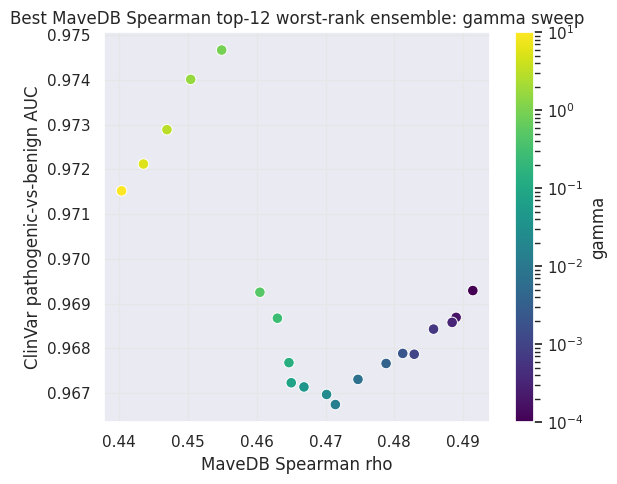

Gamma sweep summary table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_worst_rank_gamma_sweep_summary.csv
Gamma sweep scatter figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_mavedb_spearman_top12_worst_rank_gamma_spearman_auc.png
Component consistency by gamma: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/best_mavedb_spearman_top12_worst_rank_gamma_sweep/best_mavedb_spearman_top12_worst_rank_gamma_sweep_component_consistency.csv


In [12]:
if best_rank_gamma_metrics_path.is_file():
    best_rank_gamma_metrics_df = pd.read_csv(best_rank_gamma_metrics_path)
    best_rank_gamma_metrics_df["mavedb_spearman_rank"] = pd.to_numeric(best_rank_gamma_metrics_df["spearman_rho"], errors="coerce").rank(ascending=False, method="min")
    best_rank_gamma_metrics_df["auc_rank"] = pd.to_numeric(best_rank_gamma_metrics_df["auc"], errors="coerce").rank(ascending=False, method="min")
    best_rank_gamma_metrics_df["spearman_auc_rank_score"] = best_rank_gamma_metrics_df[["mavedb_spearman_rank", "auc_rank"]].mean(axis=1)
    best_rank_gamma_metrics_df = best_rank_gamma_metrics_df.sort_values(["spearman_auc_rank_score", "mavedb_spearman_rank", "auc_rank", "gamma"]).reset_index(drop=True)
    best_rank_gamma_summary_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_worst_rank_gamma_sweep_summary.csv"
    best_rank_gamma_metrics_df.to_csv(best_rank_gamma_summary_path, index=False)

    display_columns = [
        "gamma",
        "spearman_auc_rank_score",
        "mavedb_spearman_rank",
        "auc_rank",
        "spearman_rho",
        "auc",
        "mean_component_rep_consistency",
        "n_variants",
        "n_score_sequences",
    ]
    display(
        best_rank_gamma_metrics_df[[col for col in display_columns if col in best_rank_gamma_metrics_df.columns]].head(15).assign(
            gamma=lambda df: pd.to_numeric(df["gamma"], errors="coerce").map(lambda x: f"{x:.4g}"),
            spearman_auc_rank_score=lambda df: pd.to_numeric(df["spearman_auc_rank_score"], errors="coerce").round(2),
            spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
            auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
            mean_component_rep_consistency=lambda df: pd.to_numeric(df["mean_component_rep_consistency"], errors="coerce").round(3),
        )
    )

    gamma_scatter_fig = h.plot_gamma_spearman_auc_scatter(
        best_rank_gamma_metrics_df,
        best_rank_gamma_figure_path,
        "Best MaveDB Spearman top-12 worst-rank ensemble: gamma sweep",
        figure_dpi=FIGURE_DPI,
    )
    if gamma_scatter_fig is not None:
        plt.show()
    print(f"Gamma sweep summary table: {best_rank_gamma_summary_path}")
    print(f"Gamma sweep scatter figure: {best_rank_gamma_figure_path}")
    print(f"Component consistency by gamma: {best_rank_gamma_component_consistency_path}")
else:
    best_rank_gamma_metrics_df = pd.DataFrame()
    print("No gamma sweep metrics found yet.")
    print(f"Run: sbatch {best_rank_gamma_script_path}")
    print(f"Expected metrics: {best_rank_gamma_metrics_path}")

## PCA Variance Breakdown For The Best MaveDB-Spearman Top-12 PCA Concat Model

This summarizes the selected PCA components per SAE layer and the variance explained by those selected components. If both gamma-objective runs exist, the MaveDB-gamma component table is preferred; the PCA component choices are independent of gamma selection.

,model_short,model,layer,model_label,selected_pcs,selected_explained_variance_ratio,mean_selected_explained_variance_ratio,max_selected_explained_variance_ratio,first_selected_concat_component,last_selected_concat_component,available_pcs_in_component_table,available_explained_variance_ratio,selected_fraction_of_table_variance
0,ESMC-300M,biohub/ESMC-300M,29,ESMC-300M Layer_29 DeltaEmbSAE_max_pool_batcht...,64,0.2655,0.0041,0.0317,17,747,64,0.2655,1.0
1,ESMC-300M,biohub/ESMC-300M,30,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,64,0.3792,0.0059,0.0293,21,456,64,0.3792,1.0
2,ESMC-600M,biohub/ESMC-600M,13,ESMC-600M Layer_13 DeltaEmbSAE_max_pool_batcht...,64,0.3537,0.0055,0.0783,1,767,64,0.3537,1.0
3,ESMC-600M,biohub/ESMC-600M,17,ESMC-600M Layer_17 DeltaEmbSAE_max_pool_batcht...,64,0.6296,0.0098,0.1135,0,658,64,0.6296,1.0
4,ESMC-600M,biohub/ESMC-600M,29,ESMC-600M Layer_29 DeltaEmbSAE_max_pool_batcht...,64,0.4121,0.0064,0.0583,3,692,64,0.4121,1.0
5,ESMC-600M,biohub/ESMC-600M,30,ESMC-600M Layer_30 DeltaEmbSAE_max_pool_batcht...,64,0.3990,0.0062,0.0471,9,727,64,0.3990,1.0
6,ESMC-600M,biohub/ESMC-600M,31,ESMC-600M Layer_31 DeltaEmbSAE_max_pool_batcht...,64,0.3652,0.0057,0.0330,15,711,64,0.3652,1.0
7,ESMC-600M,biohub/ESMC-600M,32,ESMC-600M Layer_32 DeltaEmbSAE_max_pool_batcht...,64,0.3989,0.0062,0.0445,10,734,64,0.3989,1.0
8,ESMC-600M,biohub/ESMC-600M,33,ESMC-600M Layer_33 DeltaEmbSAE_max_pool_batcht...,64,0.3185,0.0050,0.0325,16,686,64,0.3185,1.0
9,ESMC-600M,biohub/ESMC-600M,34,ESMC-600M Layer_34 DeltaEmbSAE_max_pool_batcht...,64,0.3480,0.0054,0.0540,5,740,64,0.3480,1.0


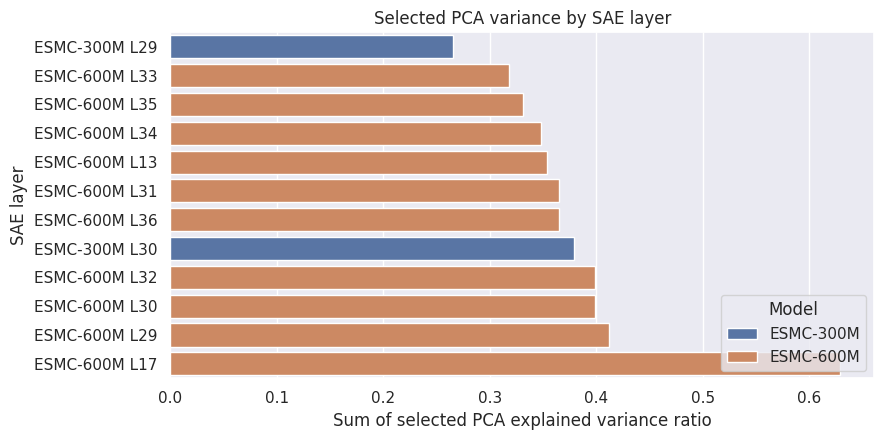

PCA component table used: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/mavedb_spearman/pca_concat__best_mavedb_spearman_top12__mavedb_spearman/pca_concat__best_mavedb_spearman_top12__mavedb_spearman_pca_components.csv
Gamma objective for selected component table: mavedb_spearman
PCA variance summary table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_variance_by_layer.csv
Selected PCA components table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_components.csv
PCA variance figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_variance_by_layer.png


In [13]:
PCA_VARIANCE_MODEL_FILTER = f"best_mavedb_spearman_top{COLLECTION_TOP_N}"
PCA_VARIANCE_OBJECTIVE_PRIORITY = {"mavedb_spearman": 0, "cross_replicate_consistency": 1}

pca_variance_component_path = None
pca_variance_objective = None

if not esmc_ensemble_metrics_df.empty and "component_table_path" in esmc_ensemble_metrics_df.columns:
    pca_variance_candidates = esmc_ensemble_metrics_df[
        esmc_ensemble_metrics_df["aggregation"].eq("pca_concat")
        & esmc_ensemble_metrics_df["model_filter"].eq(PCA_VARIANCE_MODEL_FILTER)
        & esmc_ensemble_metrics_df["component_table_path"].notna()
    ].copy()
    if not pca_variance_candidates.empty:
        if "gamma_selection_objective" not in pca_variance_candidates.columns:
            pca_variance_candidates["gamma_selection_objective"] = "cross_replicate_consistency"
        pca_variance_candidates["_objective_priority"] = pca_variance_candidates["gamma_selection_objective"].map(PCA_VARIANCE_OBJECTIVE_PRIORITY).fillna(99)
        pca_variance_candidates = pca_variance_candidates.sort_values(["_objective_priority", "gamma_selection_objective"])
        for _, candidate_row in pca_variance_candidates.iterrows():
            candidate_path = Path(candidate_row["component_table_path"])
            if candidate_path.is_file():
                pca_variance_component_path = candidate_path
                pca_variance_objective = candidate_row.get("gamma_selection_objective", "")
                break

if pca_variance_component_path is None:
    globbed_component_paths = sorted(
        (OUTPUT_ROOT / "pca_concat").glob(f"**/pca_concat__{PCA_VARIANCE_MODEL_FILTER}*_pca_components.csv"),
        key=lambda path: (0 if "__mavedb_spearman" in path.name else 1, str(path)),
    )
    for candidate_path in globbed_component_paths:
        if candidate_path.is_file():
            pca_variance_component_path = candidate_path
            pca_variance_objective = "mavedb_spearman" if "__mavedb_spearman" in candidate_path.name else "cross_replicate_consistency"
            break

if pca_variance_component_path is None:
    pca_variance_summary_df = pd.DataFrame()
    print(f"No PCA component table found for {PCA_VARIANCE_MODEL_FILTER}.")
else:
    pca_components_df = pd.read_csv(pca_variance_component_path)
    selected_flag = pca_components_df["selected"]
    if selected_flag.dtype == bool:
        selected_mask = selected_flag
    else:
        selected_mask = selected_flag.astype(str).str.lower().isin(["true", "1", "yes"])
    selected_pca_components_df = pca_components_df[selected_mask].copy()
    pca_components_df["layer"] = pd.to_numeric(pca_components_df["layer"], errors="coerce")
    selected_pca_components_df["layer"] = pd.to_numeric(selected_pca_components_df["layer"], errors="coerce")

    group_cols = ["model_short", "model", "layer", "model_label"]
    selected_summary = selected_pca_components_df.groupby(group_cols, dropna=False).agg(
        selected_pcs=("pc_idx", "count"),
        selected_explained_variance_ratio=("explained_variance_ratio", "sum"),
        mean_selected_explained_variance_ratio=("explained_variance_ratio", "mean"),
        max_selected_explained_variance_ratio=("explained_variance_ratio", "max"),
        first_selected_concat_component=("concat_component_idx", "min"),
        last_selected_concat_component=("concat_component_idx", "max"),
    ).reset_index()
    available_summary = pca_components_df.groupby(group_cols, dropna=False).agg(
        available_pcs_in_component_table=("pc_idx", "count"),
        available_explained_variance_ratio=("explained_variance_ratio", "sum"),
    ).reset_index()
    pca_variance_summary_df = selected_summary.merge(available_summary, on=group_cols, how="left")
    pca_variance_summary_df["selected_fraction_of_table_variance"] = (
        pca_variance_summary_df["selected_explained_variance_ratio"] / pca_variance_summary_df["available_explained_variance_ratio"]
    )
    pca_variance_summary_df = pca_variance_summary_df.sort_values(["model_short", "layer"]).reset_index(drop=True)

    pca_variance_summary_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_variance_by_layer.csv"
    pca_variance_selected_components_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_components.csv"
    pca_variance_figure_path = paths.figure_dir / "BRCA1_best_mavedb_spearman_top12_pca_concat_selected_pca_variance_by_layer.png"
    pca_variance_summary_df.to_csv(pca_variance_summary_path, index=False)
    selected_pca_components_df.to_csv(pca_variance_selected_components_path, index=False)

    display(
        pca_variance_summary_df.assign(
            layer=lambda df: pd.to_numeric(df["layer"], errors="coerce").astype("Int64"),
            selected_explained_variance_ratio=lambda df: pd.to_numeric(df["selected_explained_variance_ratio"], errors="coerce").round(4),
            available_explained_variance_ratio=lambda df: pd.to_numeric(df["available_explained_variance_ratio"], errors="coerce").round(4),
            selected_fraction_of_table_variance=lambda df: pd.to_numeric(df["selected_fraction_of_table_variance"], errors="coerce").round(3),
            mean_selected_explained_variance_ratio=lambda df: pd.to_numeric(df["mean_selected_explained_variance_ratio"], errors="coerce").round(4),
            max_selected_explained_variance_ratio=lambda df: pd.to_numeric(df["max_selected_explained_variance_ratio"], errors="coerce").round(4),
        )
    )

    plot_df = pca_variance_summary_df.copy()
    plot_df["layer_label"] = plot_df["model_short"].astype(str) + " L" + pd.to_numeric(plot_df["layer"], errors="coerce").astype("Int64").astype(str)
    plot_df = plot_df.sort_values("selected_explained_variance_ratio", ascending=True)
    fig, ax = plt.subplots(figsize=(9.0, max(4.0, 0.38 * len(plot_df))))
    sns.barplot(
        data=plot_df,
        y="layer_label",
        x="selected_explained_variance_ratio",
        hue="model_short",
        dodge=False,
        ax=ax,
    )
    ax.set_xlabel("Sum of selected PCA explained variance ratio")
    ax.set_ylabel("SAE layer")
    ax.set_title("Selected PCA variance by SAE layer")
    ax.legend(title="Model", loc="lower right")
    fig.tight_layout()
    fig.savefig(pca_variance_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

    print(f"PCA component table used: {pca_variance_component_path}")
    print(f"Gamma objective for selected component table: {pca_variance_objective}")
    print(f"PCA variance summary table: {pca_variance_summary_path}")
    print(f"Selected PCA components table: {pca_variance_selected_components_path}")
    print(f"PCA variance figure: {pca_variance_figure_path}")

## Plot Against Previous Layer-Level Results

This plot overlays the new ESM-C ensemble methods onto the existing layer-level Spearman/AUC results from `lower_context.ipynb`.

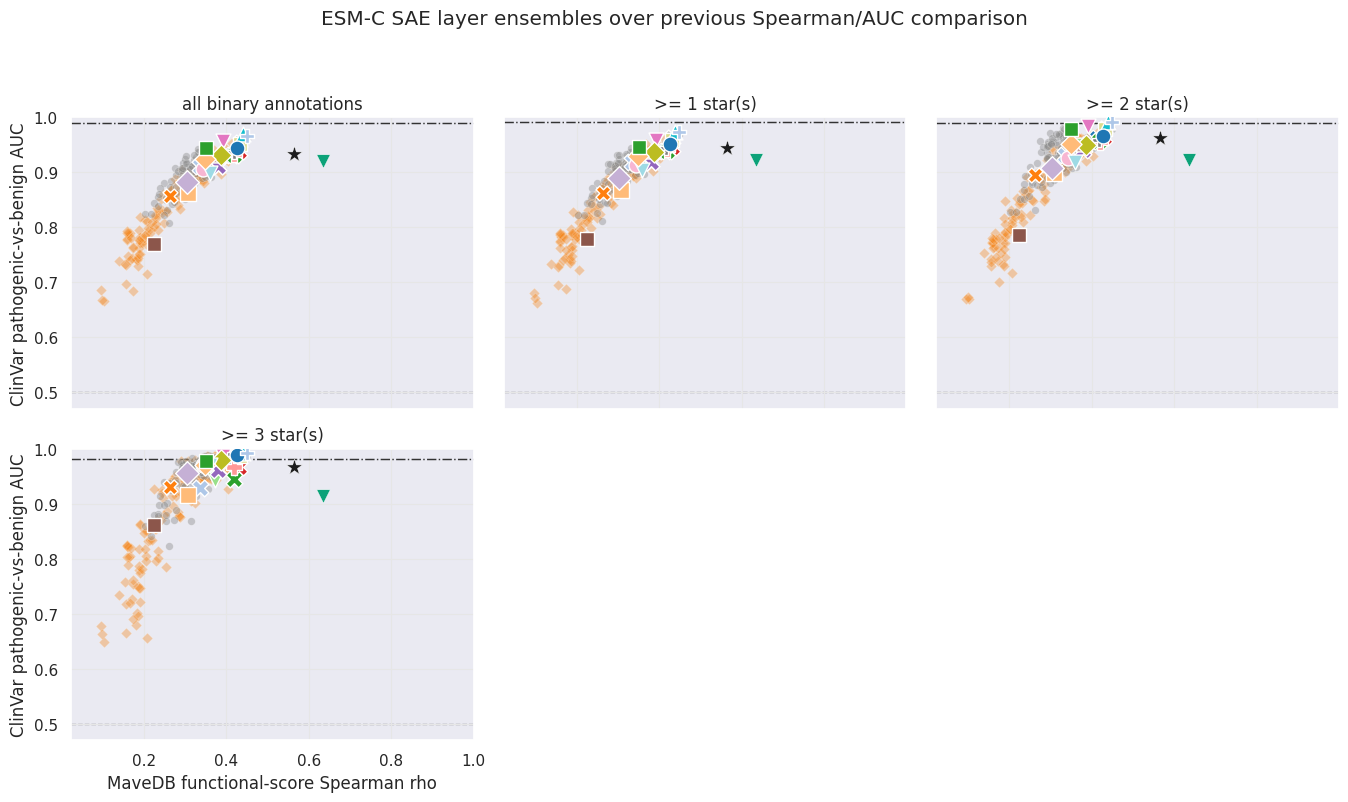

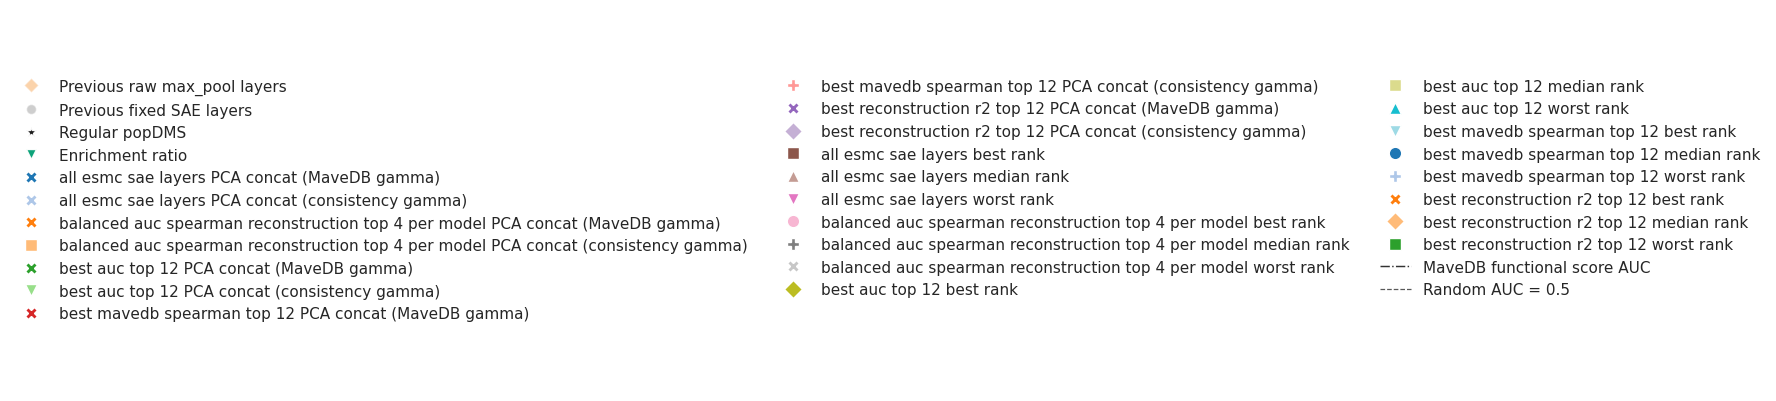

,review_filter,method_label,gamma_selection_objective,model_filter,spearman_rho,auc,n_variants
0,all binary annotations,all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,0.931,496
1,>= 1 star(s),all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,0.939,491
2,>= 2 star(s),all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,0.962,282
3,>= 3 star(s),all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,0.978,132
4,>= 4 star(s),all esmc sae layers PCA concat (MaveDB gamma),mavedb_spearman,all_esmc_sae_layers,0.413,NaN,0
...,...,...,...,...,...,...,...
120,all binary annotations,best reconstruction r2 top 12 worst rank,not_applicable,best_reconstruction_r2_top12,0.350,0.944,496
121,>= 1 star(s),best reconstruction r2 top 12 worst rank,not_applicable,best_reconstruction_r2_top12,0.350,0.947,491
122,>= 2 star(s),best reconstruction r2 top 12 worst rank,not_applicable,best_reconstruction_r2_top12,0.350,0.978,282
123,>= 3 star(s),best reconstruction r2 top 12 worst rank,not_applicable,best_reconstruction_r2_top12,0.350,0.978,132


Combined figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_esmc_sae_layer_ensemble_with_previous_spearman_auc_by_review_stars.png
Separate legend figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_esmc_sae_layer_ensemble_spearman_auc_legend.png
Spearman/AUC plot rows table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_esmc_sae_layer_ensemble_spearman_auc_plot_rows.csv


In [14]:
if not esmc_ensemble_metrics_df.empty:
    previous_df = h.load_previous_metrics_for_combined_plot(
        all_binary_table_path=paths.spearman_auc_table_path,
        table_dir=paths.table_dir,
        star_combined_table_path=paths.spearman_auc_star_combined_table_path,
    )
    spearman_auc_plot_rows_path = paths.table_dir / "BRCA1_esmc_sae_layer_ensemble_spearman_auc_plot_rows.csv"
    esmc_ensemble_metrics_df.to_csv(spearman_auc_plot_rows_path, index=False)

    marker_cycle = ["P", "X", "D", "s", "^", "v", "o"]
    color_cycle = sns.color_palette("tab20", n_colors=max(20, esmc_ensemble_metrics_df["method_label"].nunique()))
    marker_specs = {}
    for idx, method_label in enumerate(esmc_ensemble_metrics_df["method_label"].drop_duplicates()):
        is_mavedb_gamma = "MaveDB gamma" in method_label
        marker_specs[method_label] = {
            "marker": "X" if is_mavedb_gamma else marker_cycle[idx % len(marker_cycle)],
            "size": 145 if "PCA" in method_label else 115,
            "color": color_cycle[idx % len(color_cycle)],
            "offset": (6, -9),
        }

    combined_figure_path = paths.figure_dir / "BRCA1_esmc_sae_layer_ensemble_with_previous_spearman_auc_by_review_stars.png"
    fig = h.plot_ensemble_with_previous(
        previous_df,
        esmc_ensemble_metrics_df,
        combined_figure_path,
        "ESM-C SAE layer ensembles over previous Spearman/AUC comparison",
        marker_specs,
        figure_dpi=FIGURE_DPI,
        review_star_thresholds=[1, 2, 3],
        annotate_points=False,
        include_legend=False,
    )
    plt.show()

    legend_figure_path = paths.figure_dir / "BRCA1_esmc_sae_layer_ensemble_spearman_auc_legend.png"
    legend_fig = h.plot_ensemble_comparison_legend(
        marker_specs,
        legend_figure_path,
        figure_dpi=FIGURE_DPI,
        ncol=3,
    )
    plt.show()

    display(
        esmc_ensemble_metrics_df[
            ["review_filter", "method_label", "gamma_selection_objective", "model_filter", "spearman_rho", "auc", "n_variants"]
        ].assign(
            spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
            auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        )
    )
    print(f"Combined figure: {combined_figure_path}")
    print(f"Separate legend figure: {legend_figure_path}")
    print(f"Spearman/AUC plot rows table: {spearman_auc_plot_rows_path}")
else:
    print("No ensemble metrics are available yet. Run or collect the ensemble task outputs first.")

## Gamma Consistency Plot Locations

Every PCA-concat task saves its cross-replicate consistency by gamma plot as `*_gamma_consistency.png`. The table below lists those exact paths.

,method_label,model_filter,gamma_opt,gamma_plot_path,gamma_table_path
0,all esmc sae layers PCA concat (MaveDB gamma),all_esmc_sae_layers,0.010000,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,all esmc sae layers PCA concat (consistency ga...,all_esmc_sae_layers,3.359818,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,balanced auc spearman reconstruction top 4 per...,balanced_auc_spearman_reconstruction_top4_per_...,0.042813,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,balanced auc spearman reconstruction top 4 per...,balanced_auc_spearman_reconstruction_top4_per_...,127.427499,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,best auc top 12 PCA concat (MaveDB gamma),best_auc_top12,0.020691,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
5,best auc top 12 PCA concat (consistency gamma),best_auc_top12,1.623777,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
6,best mavedb spearman top 12 PCA concat (MaveDB...,best_mavedb_spearman_top12,0.010000,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
7,best mavedb spearman top 12 PCA concat (consis...,best_mavedb_spearman_top12,0.183298,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
8,best reconstruction r2 top 12 PCA concat (Mave...,best_reconstruction_r2_top12,0.010000,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
9,best reconstruction r2 top 12 PCA concat (cons...,best_reconstruction_r2_top12,0.784760,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


**all esmc sae layers PCA concat (MaveDB gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/mavedb_spearman/pca_concat__all_esmc_sae_layers__mavedb_spearman/pca_concat__all_esmc_sae_layers__mavedb_spearman_mavedb_spearman_gamma_diagnostics.png`

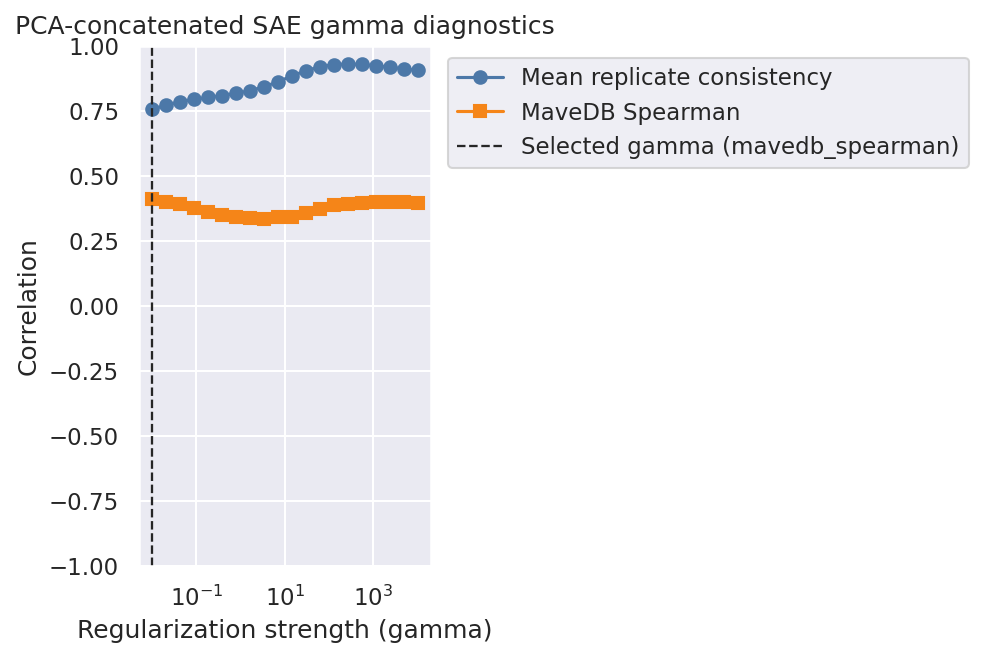

**all esmc sae layers PCA concat (consistency gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/pca_concat__all_esmc_sae_layers/pca_concat__all_esmc_sae_layers_gamma_consistency.png`

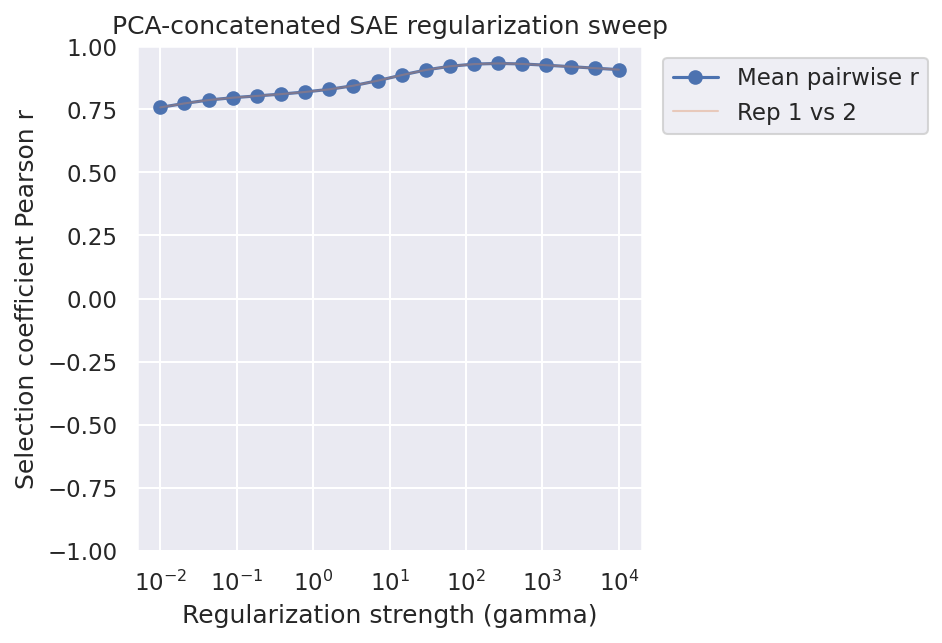

**balanced auc spearman reconstruction top 4 per model PCA concat (MaveDB gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/mavedb_spearman/pca_concat__balanced_auc_spearman_reconstruction_top4_per_model__mavedb_spearman/pca_concat__balanced_auc_spearman_reconstruction_top4_per_model__mavedb_spearman_mavedb_spearman_gamma_diagnostics.png`

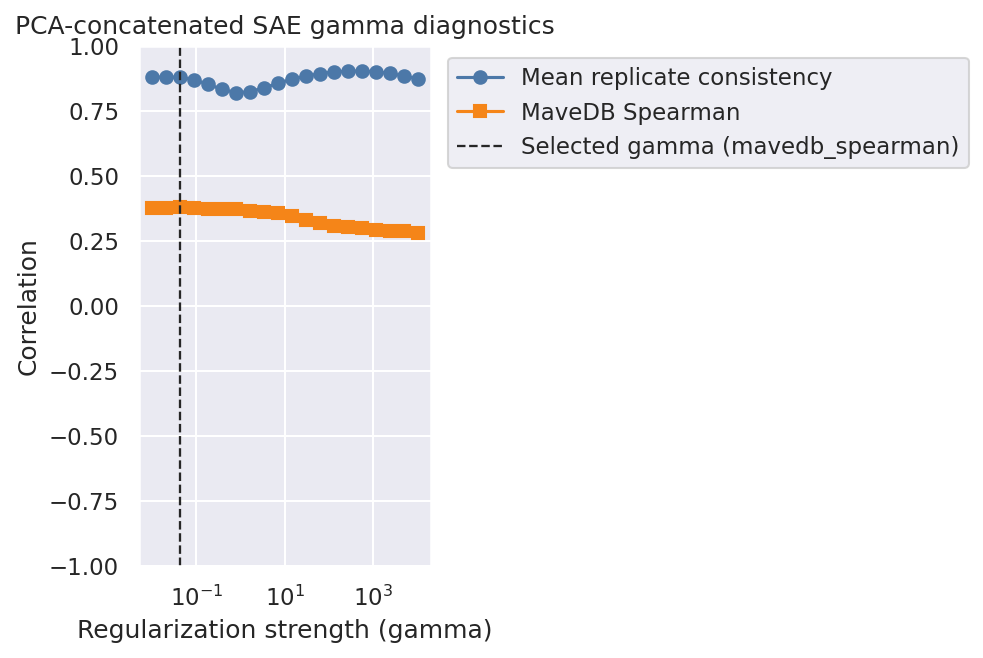

**balanced auc spearman reconstruction top 4 per model PCA concat (consistency gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/pca_concat__balanced_auc_spearman_reconstruction_top4_per_model/pca_concat__balanced_auc_spearman_reconstruction_top4_per_model_gamma_consistency.png`

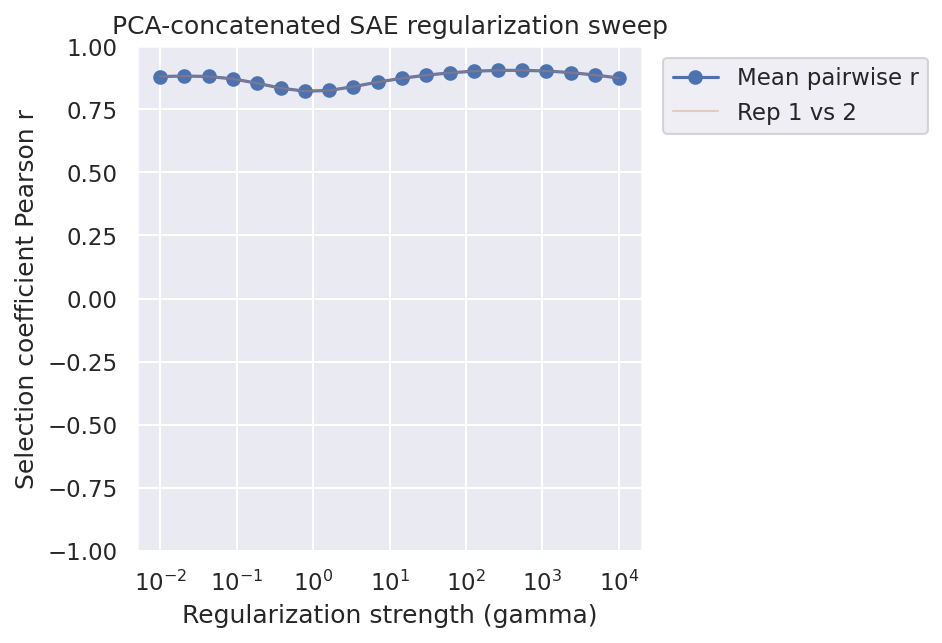

**best auc top 12 PCA concat (MaveDB gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/mavedb_spearman/pca_concat__best_auc_top12__mavedb_spearman/pca_concat__best_auc_top12__mavedb_spearman_mavedb_spearman_gamma_diagnostics.png`

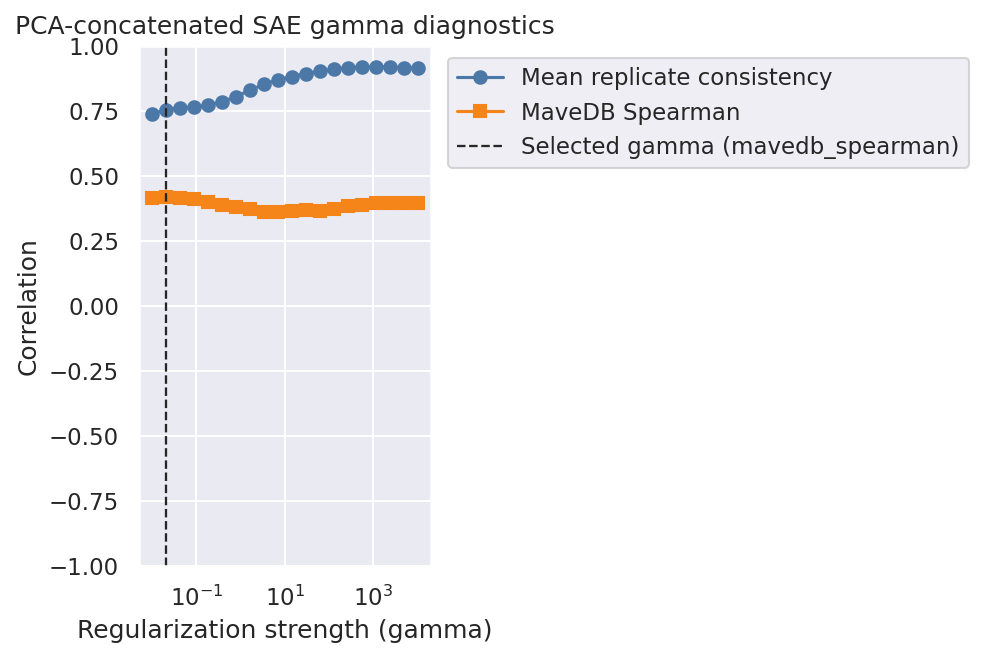

**best auc top 12 PCA concat (consistency gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/pca_concat__best_auc_top12/pca_concat__best_auc_top12_gamma_consistency.png`

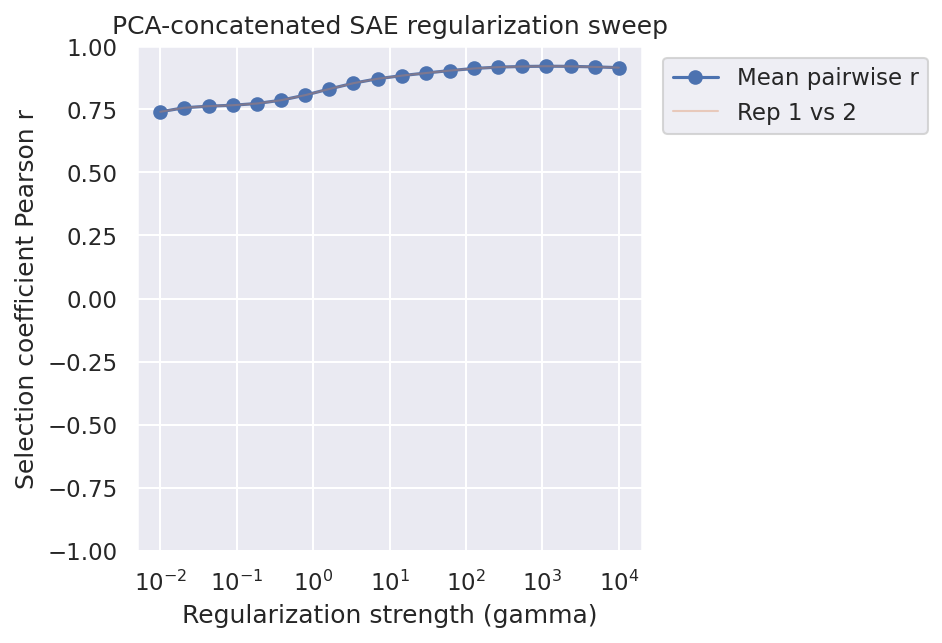

**best mavedb spearman top 12 PCA concat (MaveDB gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/mavedb_spearman/pca_concat__best_mavedb_spearman_top12__mavedb_spearman/pca_concat__best_mavedb_spearman_top12__mavedb_spearman_mavedb_spearman_gamma_diagnostics.png`

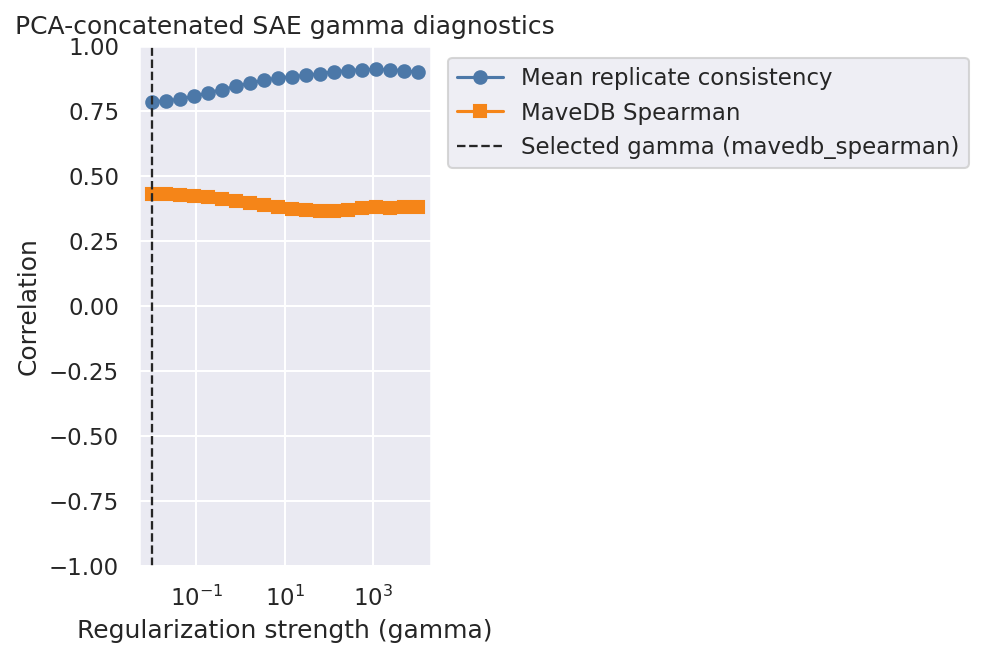

**best mavedb spearman top 12 PCA concat (consistency gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/pca_concat__best_mavedb_spearman_top12/pca_concat__best_mavedb_spearman_top12_gamma_consistency.png`

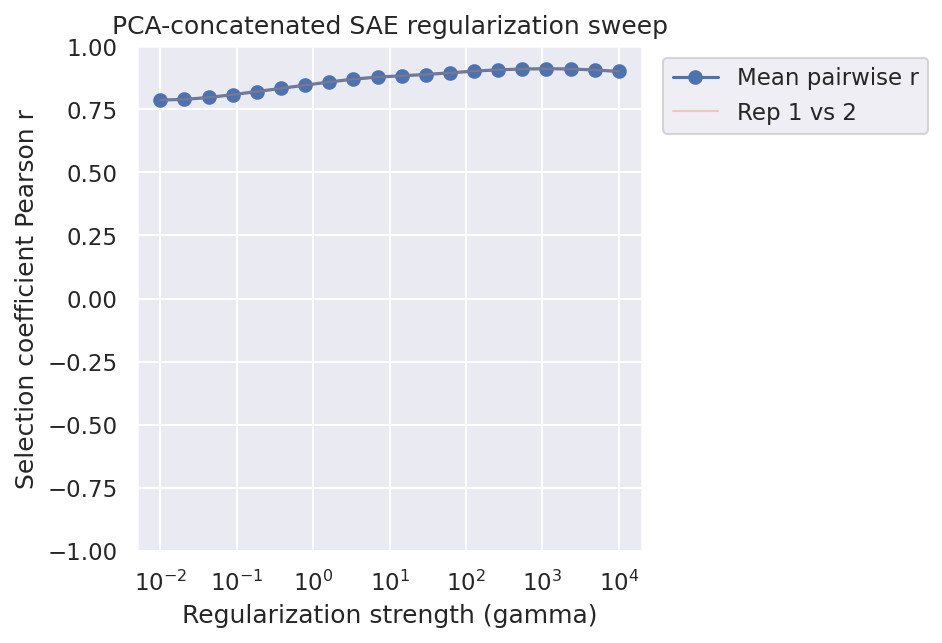

**best reconstruction r2 top 12 PCA concat (MaveDB gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/mavedb_spearman/pca_concat__best_reconstruction_r2_top12__mavedb_spearman/pca_concat__best_reconstruction_r2_top12__mavedb_spearman_mavedb_spearman_gamma_diagnostics.png`

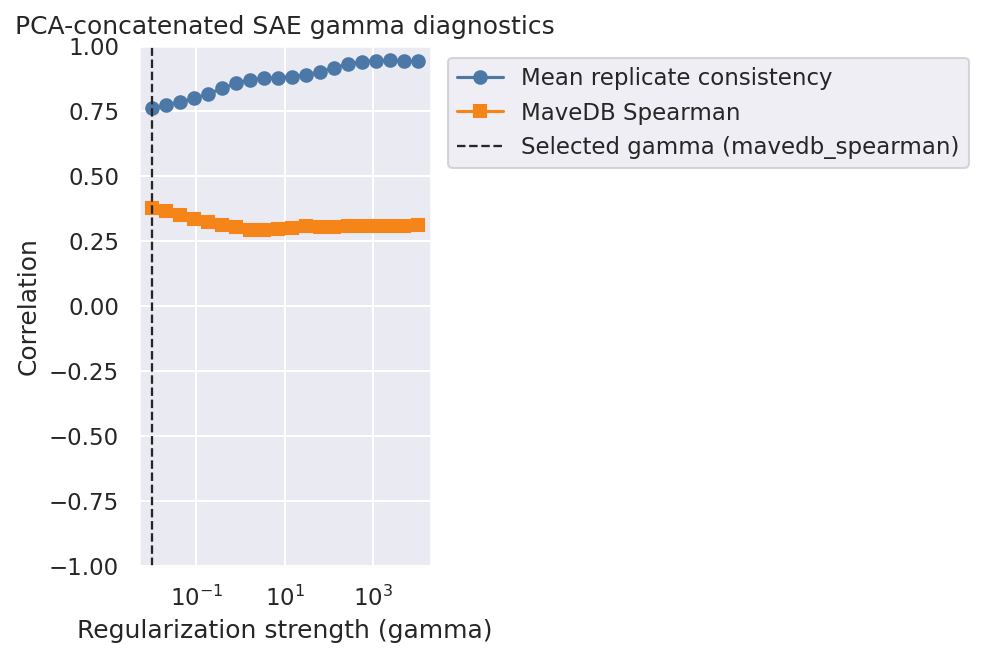

**best reconstruction r2 top 12 PCA concat (consistency gamma)**  
`/net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat/pca_concat__best_reconstruction_r2_top12/pca_concat__best_reconstruction_r2_top12_gamma_consistency.png`

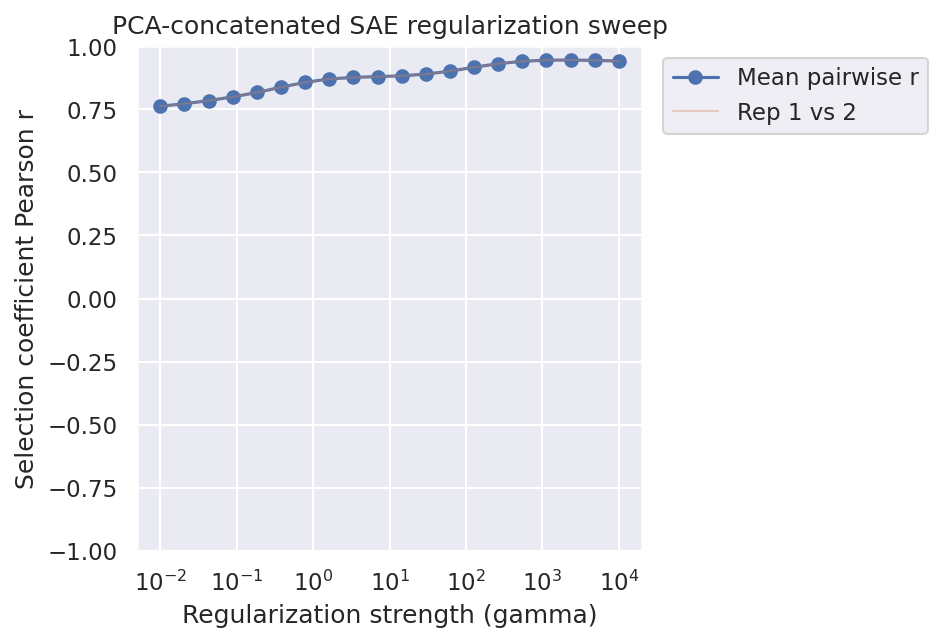

PCA gamma consistency directory: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/pca_concat


In [15]:
if not esmc_ensemble_metrics_df.empty and "gamma_plot_path" in esmc_ensemble_metrics_df.columns:
    gamma_columns = ["method_label", "model_filter", "gamma_opt", "gamma_plot_path"]
    if "gamma_table_path" in esmc_ensemble_metrics_df.columns:
        gamma_columns.append("gamma_table_path")
    gamma_plot_df = (
        esmc_ensemble_metrics_df.dropna(subset=["gamma_plot_path"])
        .loc[lambda df: df["gamma_plot_path"].astype(str).ne("")]
        [gamma_columns]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    display(gamma_plot_df)
    for _, row in gamma_plot_df.iterrows():
        plot_path = Path(row["gamma_plot_path"])
        display(Markdown(f"**{row['method_label']}**  \n`{plot_path}`"))
        if plot_path.is_file():
            display(Image(filename=str(plot_path), width=780))
        else:
            print(f"Missing gamma plot: {plot_path}")
print(f"PCA gamma consistency directory: {OUTPUT_ROOT / 'pca_concat'}")


## Task Status Audit

In [16]:
status_files = sorted((OUTPUT_ROOT / "status").glob("*_status.json"))
status_rows = []
for status_path in status_files:
    with status_path.open() as handle:
        row = __import__("json").load(handle)
    row["status_path"] = str(status_path)
    status_rows.append(row)
status_df = pd.DataFrame(status_rows)
if not status_df.empty:
    display(status_df[[col for col in ["task_idx", "status", "task_type", "collection_name", "aggregation", "n_sources", "n_selected_components", "gamma_plot_path", "error", "status_path"] if col in status_df.columns]])
else:
    print(f"No status files found yet under {OUTPUT_ROOT / 'status'}")

,task_idx,status,task_type,collection_name,aggregation,n_sources,n_selected_components,gamma_plot_path,status_path
0,0,ok,pca_concat,all_esmc_sae_layers,NaN,66,1000.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,0,ok,rank_ensemble,all_esmc_sae_layers,rank_median,66,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,1,ok,pca_concat,best_auc_top12,NaN,12,768.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,1,ok,rank_ensemble,all_esmc_sae_layers,rank_worst,66,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,2,ok,pca_concat,best_mavedb_spearman_top12,NaN,12,768.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
5,2,ok,rank_ensemble,all_esmc_sae_layers,rank_best,66,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
6,3,ok,pca_concat,best_reconstruction_r2_top12,NaN,12,768.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
7,3,ok,rank_ensemble,best_auc_top12,rank_median,12,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
8,4,ok,pca_concat,balanced_auc_spearman_reconstruction_top4_per_...,NaN,8,512.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
9,4,ok,rank_ensemble,best_auc_top12,rank_worst,12,NaN,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Best Model Fitness Distribution By ClinVar Review Stars

Distribution of the top-ranked ensemble's fitness (rank) scores for ClinVar pathogenic vs. benign variants, paneled by review-star threshold. Pathogenic and benign histograms share bins and are drawn translucent so their overlap is visible, and each panel reports the corresponding AUC.

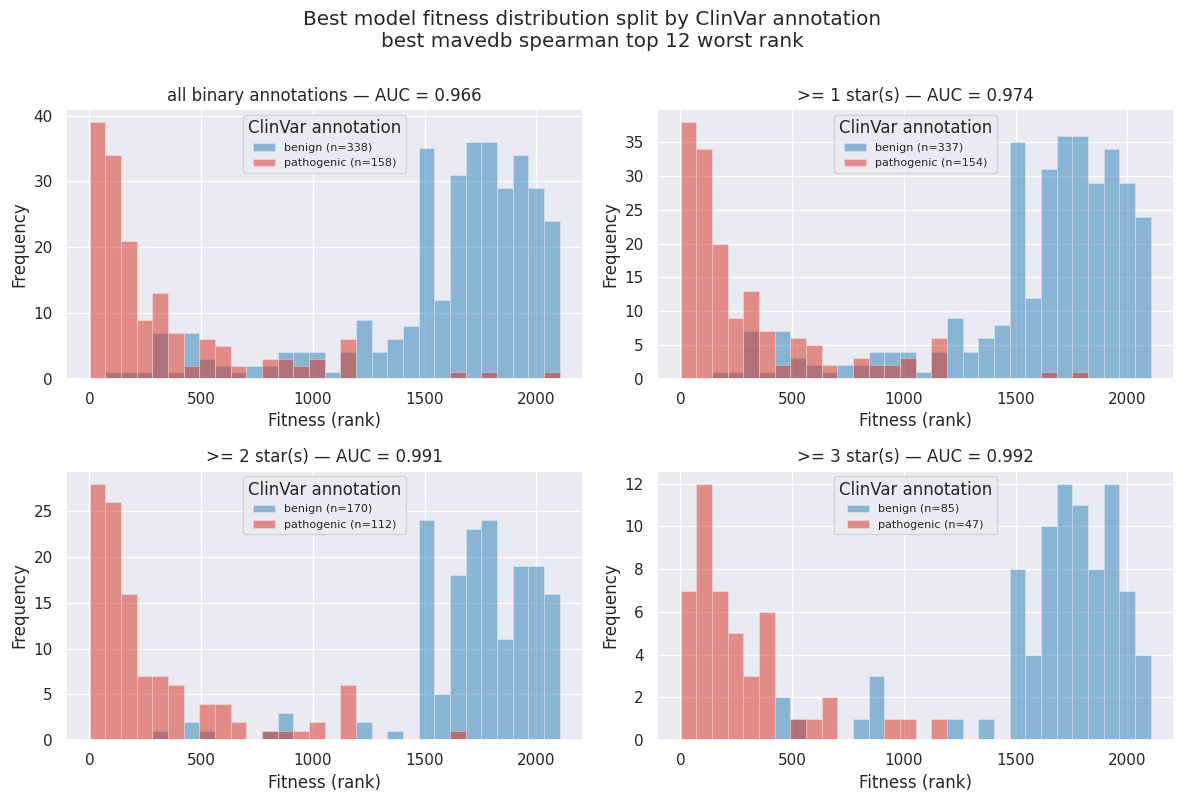

Best model (Spearman/AUC rank 1): best mavedb spearman top 12 worst rank
Best model fitness distribution figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_model_fitness_distribution_by_review_stars.png


In [17]:
# Best-model fitness-score distribution split by ClinVar pathogenic/benign across review-star thresholds.
if not performance_summary_df.empty:
    best_model_row = performance_summary_df.sort_values("spearman_auc_rank").iloc[0]
    best_model_label = best_model_row["method_label"]
    best_model_fitness_path = h.as_existing_path(best_model_row.get("fitness_path", ""))

    if best_model_fitness_path is None:
        print(f"No fitness table found for best model {best_model_label!r}; cannot plot score distributions.")
    else:
        best_fitness_df = pd.read_csv(best_model_fitness_path)[["SequenceIndex", "fitness"]].copy()
        best_fitness_df["SequenceIndex"] = best_fitness_df["SequenceIndex"].astype(str)
        best_fitness_df["fitness"] = pd.to_numeric(best_fitness_df["fitness"], errors="coerce")
        best_fitness_df = best_fitness_df.dropna(subset=["fitness"])

        pathogenicity_palette = {"benign": "#2c7fb8", "pathogenic": "#d7301f"}
        star_panels = []
        for min_review_stars, review_filter in h.review_star_specs():
            annotation_map = h.clinvar_binary_annotation_map(
                paths.clinvar_annotation_cache_path,
                primary_key="hgvs_nt",
                min_review_stars=min_review_stars,
            )
            panel_df = best_fitness_df.copy()
            panel_df["annotation"] = panel_df["SequenceIndex"].map(annotation_map)
            panel_df = panel_df[panel_df["annotation"].isin(["benign", "pathogenic"])].dropna(subset=["fitness"])
            if panel_df.empty:
                continue
            panel_auc = h.classification_metrics_for_fitness(panel_df)["auc"]
            star_panels.append((min_review_stars, review_filter, panel_df, panel_auc))

        if not star_panels:
            print("No pathogenic/benign annotated variants overlap the best-model fitness scores.")
        else:
            # Shared bins so the translucent pathogenic/benign overlap is comparable across panels.
            all_fitness = best_fitness_df["fitness"].to_numpy(dtype=float)
            bin_edges = np.linspace(np.nanmin(all_fitness), np.nanmax(all_fitness), 31)

            ncols = min(len(star_panels), 2)
            nrows = int(np.ceil(len(star_panels) / ncols))
            fig, axes = plt.subplots(nrows, ncols, figsize=(6.0 * ncols, 4.0 * nrows), squeeze=False)
            axes_flat = axes.ravel()
            for ax, (min_review_stars, review_filter, panel_df, panel_auc) in zip(axes_flat, star_panels):
                for annotation in ["benign", "pathogenic"]:
                    values = panel_df.loc[panel_df["annotation"].eq(annotation), "fitness"].to_numpy(dtype=float)
                    ax.hist(
                        values,
                        bins=bin_edges,
                        color=pathogenicity_palette[annotation],
                        alpha=0.5,
                        label=f"{annotation} (n={len(values)})",
                        edgecolor="white",
                        linewidth=0.4,
                    )
                ax.set_title(f"{review_filter} \u2014 AUC = {panel_auc:.3f}")
                ax.set_xlabel("Fitness (rank)")
                ax.set_ylabel("Frequency")
                ax.legend(title="ClinVar annotation", fontsize=8)
            for ax in axes_flat[len(star_panels):]:
                ax.axis("off")
            fig.suptitle(
                f"Best model fitness distribution split by ClinVar annotation\n{best_model_label}",
                y=1.0,
            )
            fig.tight_layout()
            best_model_distribution_figure_path = paths.figure_dir / "BRCA1_best_model_fitness_distribution_by_review_stars.png"
            fig.savefig(best_model_distribution_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
            plt.show()
            print(f"Best model (Spearman/AUC rank 1): {best_model_label}")
            print(f"Best model fitness distribution figure: {best_model_distribution_figure_path}")
else:
    print("No performance summary is available yet. Run or collect the ensemble task outputs first.")


## Best Model Per-Component Contribution (Worst-Rank Source)

The best ensemble aggregates the 12 chosen SAE model/layers by taking the worst (minimum) per-variant rank across components. For each variant the worst rank is supplied by exactly one component, so counting how often each component is that source shows how much each of the 12 chosen models drives the population's fitness scores.

,component,n_variants_selected,model_short,spearman_rho,spearman_rho_rank,fraction
0,ESMC-600M_L32,528,ESMC-600M,0.421,4,0.251
1,ESMC-300M_L30,305,ESMC-300M,0.439,2,0.145
2,ESMC-600M_L36,277,ESMC-600M,0.449,1,0.132
3,ESMC-600M_L17,160,ESMC-600M,0.365,12,0.076
4,ESMC-600M_L33,147,ESMC-600M,0.412,6,0.070
5,ESMC-600M_L13,142,ESMC-600M,0.371,11,0.067
6,ESMC-600M_L35,125,ESMC-600M,0.402,7,0.059
7,ESMC-300M_L29,112,ESMC-300M,0.415,5,0.053
8,ESMC-600M_L34,107,ESMC-600M,0.424,3,0.051
9,ESMC-600M_L29,95,ESMC-600M,0.371,10,0.045


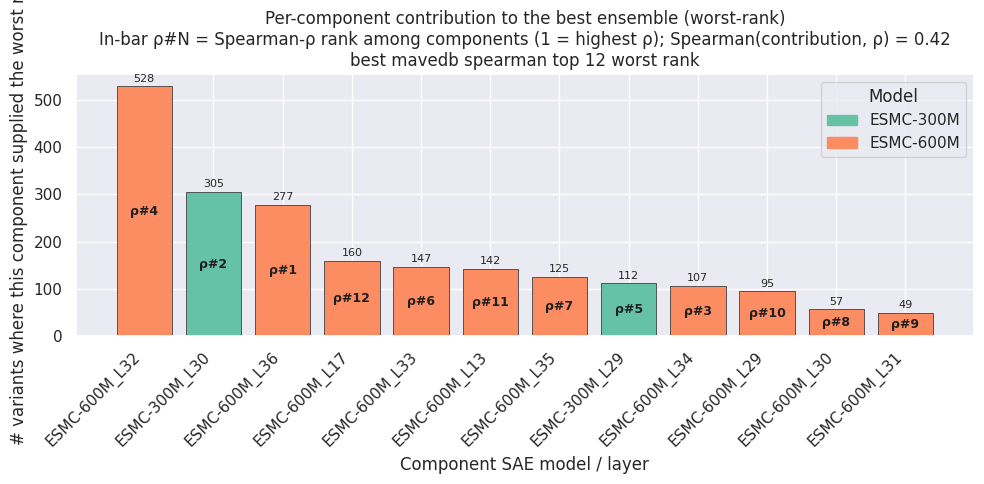

Best model (worst-rank): best mavedb spearman top 12 worst rank
Spearman correlation between contribution count and component rho: 0.420
Component contribution table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_model_worst_rank_component_contributions.csv
Component contribution figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_model_worst_rank_component_contributions.png


In [18]:
# How much each of the 12 chosen components drives the best ensemble: for each variant, count
# which component supplied the selected (worst) rank that the rank_worst aggregation keeps.
# Each bar is annotated with that component's Spearman-rho rank among the 12 so the link
# between contribution and agreement with the MaveDB functional scores is visible.
if not performance_summary_df.empty:
    best_model_row = performance_summary_df.sort_values("spearman_auc_rank").iloc[0]
    best_model_label = best_model_row["method_label"]
    best_model_aggregation = best_model_row["aggregation"]
    best_model_collection = best_model_row["model_filter"]

    if best_model_aggregation not in {"rank_worst", "rank_best"}:
        print(
            f"Best model {best_model_label!r} uses aggregation {best_model_aggregation!r}; "
            "per-component rank attribution only applies to rank_worst / rank_best ensembles."
        )
    elif best_model_collection not in collections:
        print(f"Collection {best_model_collection!r} for the best model is not in `collections`.")
    else:
        # Rebuild the component score matrix exactly as aggregate_fitness_rows does, and label
        # each component the same way load_ensemble_fitness_series names its series.
        component_rows = collections[best_model_collection].copy()

        def _component_label(row):
            layer = row.get("layer")
            layer = int(layer) if pd.notna(layer) and np.isfinite(float(layer)) else layer
            return f"{row.get('model_short', row.get('model', 'model'))}_L{layer}"

        component_rows["component"] = component_rows.apply(_component_label, axis=1)
        component_rows["spearman_rho"] = pd.to_numeric(component_rows["spearman_rho"], errors="coerce")
        component_rows["spearman_rho_rank"] = (
            component_rows["spearman_rho"].rank(ascending=False, method="min").astype("Int64")
        )

        component_series = [h.load_ensemble_fitness_series(row) for _, row in component_rows.iterrows()]
        component_score_matrix = pd.concat(component_series, axis=1)
        component_rank_matrix = component_score_matrix.rank(method="average", ascending=True)

        # rank_worst keeps the minimum rank per variant; rank_best keeps the maximum.
        valid_variants = component_score_matrix.notna().sum(axis=1).gt(0)
        if best_model_aggregation == "rank_worst":
            selection_word = "worst"
            selected_component = component_rank_matrix[valid_variants].idxmin(axis=1)
        else:
            selection_word = "best"
            selected_component = component_rank_matrix[valid_variants].idxmax(axis=1)

        contribution_df = (
            selected_component.value_counts()
            .reindex(component_score_matrix.columns, fill_value=0)
            .rename_axis("component")
            .reset_index(name="n_variants_selected")
        )
        contribution_df = contribution_df.merge(
            component_rows[["component", "model_short", "spearman_rho", "spearman_rho_rank"]],
            on="component",
            how="left",
        )
        contribution_df["fraction"] = (
            contribution_df["n_variants_selected"] / contribution_df["n_variants_selected"].sum()
        )
        contribution_df = contribution_df.sort_values("n_variants_selected", ascending=False).reset_index(drop=True)

        # Is contribution related to functional-score agreement (Spearman rho)?
        corr_input = contribution_df[["n_variants_selected", "spearman_rho"]].dropna()
        contribution_vs_rho = (
            corr_input["n_variants_selected"].corr(corr_input["spearman_rho"], method="spearman")
            if len(corr_input) >= 3
            else np.nan
        )

        component_contribution_path = paths.table_dir / "BRCA1_best_model_worst_rank_component_contributions.csv"
        contribution_df.to_csv(component_contribution_path, index=False)
        display(
            contribution_df.assign(
                fraction=lambda d: d["fraction"].round(3),
                spearman_rho=lambda d: d["spearman_rho"].round(3),
            )
        )

        family_palette = {
            short: color
            for short, color in zip(
                sorted(contribution_df["model_short"].unique()),
                sns.color_palette("Set2", n_colors=contribution_df["model_short"].nunique()),
            )
        }
        bar_colors = contribution_df["model_short"].map(family_palette)
        fig, ax = plt.subplots(figsize=(10.0, 5.0))
        bars = ax.bar(
            contribution_df["component"],
            contribution_df["n_variants_selected"],
            color=bar_colors,
            edgecolor="0.25",
            linewidth=0.6,
        )
        ax.bar_label(bars, padding=2, fontsize=8)
        # Spearman-rho rank printed inside each bar (1 = highest rho among the 12 components).
        for bar, rho_rank in zip(bars, contribution_df["spearman_rho_rank"]):
            if pd.isna(rho_rank):
                continue
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f"\u03c1#{int(rho_rank)}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="0.12",
            )
        ax.set_xlabel("Component SAE model / layer")
        ax.set_ylabel(f"# variants where this component supplied the {selection_word} rank")
        ax.set_title(
            f"Per-component contribution to the best ensemble ({selection_word}-rank)\n"
            f"In-bar \u03c1#N = Spearman-\u03c1 rank among components (1 = highest \u03c1); "
            f"Spearman(contribution, \u03c1) = {contribution_vs_rho:.2f}\n{best_model_label}"
        )
        ax.tick_params(axis="x", rotation=45)
        for tick_label in ax.get_xticklabels():
            tick_label.set_ha("right")
        legend_handles = [plt.Rectangle((0, 0), 1, 1, color=family_palette[short]) for short in family_palette]
        ax.legend(legend_handles, list(family_palette), title="Model", loc="upper right")
        fig.tight_layout()
        component_contribution_figure_path = paths.figure_dir / "BRCA1_best_model_worst_rank_component_contributions.png"
        fig.savefig(component_contribution_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
        plt.show()
        print(f"Best model ({selection_word}-rank): {best_model_label}")
        print(f"Spearman correlation between contribution count and component rho: {contribution_vs_rho:.3f}")
        print(f"Component contribution table: {component_contribution_path}")
        print(f"Component contribution figure: {component_contribution_figure_path}")
else:
    print("No performance summary is available yet. Run or collect the ensemble task outputs first.")


## Per-SAE Gamma Sweep And Multi-Gamma Ensemble Comparison

This section is appended so it does not feed back into the earlier analyses. It creates one Slurm array task per selected SAE layer, then combines the finished per-SAE gamma sweeps into single-gamma, multi-gamma, and current cross-replicate baseline comparisons.


In [19]:
# Per-SAE gamma sweep configuration. These outputs intentionally use a distinct run name.
PER_SAE_GAMMA_COLLECTION = f"best_mavedb_spearman_top{COLLECTION_TOP_N}"
PER_SAE_GAMMA_AGGREGATION = "rank_worst"
PER_SAE_GAMMA_MIN = 0.0001
PER_SAE_GAMMA_MAX = 10
PER_SAE_GAMMA_STEPS = 20
PER_SAE_GAMMA_VALUES = np.logspace(
    np.log10(PER_SAE_GAMMA_MIN),
    np.log10(PER_SAE_GAMMA_MAX),
    PER_SAE_GAMMA_STEPS,
)
PER_SAE_SHARED_GAMMA_BASELINE = 1.0
PER_SAE_GAMMA_VALUES = np.unique(
    np.concatenate([PER_SAE_GAMMA_VALUES, np.array([PER_SAE_SHARED_GAMMA_BASELINE])])
)

CREATE_PER_SAE_GAMMA_SWEEP_JOBS = False
SUBMIT_PER_SAE_GAMMA_SWEEP_JOBS = False
PER_SAE_GAMMA_SWEEP_MEM = "96G"
PER_SAE_GAMMA_SWEEP_TIME = "12:00:00"
PER_SAE_GAMMA_MAX_ACTIVE_TASKS = min(COLLECTION_TOP_N, 12)

assert PER_SAE_GAMMA_COLLECTION in collections, f"Missing collection: {PER_SAE_GAMMA_COLLECTION}"
per_sae_gamma_source_rows = collections[PER_SAE_GAMMA_COLLECTION].copy().reset_index(drop=True)
assert len(per_sae_gamma_source_rows) == COLLECTION_TOP_N, len(per_sae_gamma_source_rows)

PER_SAE_GAMMA_RUN_NAME = f"{PER_SAE_GAMMA_COLLECTION}_{PER_SAE_GAMMA_AGGREGATION}_per_sae_gamma_sweep"
PER_SAE_GAMMA_OUTPUT_DIR = OUTPUT_ROOT / PER_SAE_GAMMA_RUN_NAME
PER_SAE_GAMMA_STATUS_DIR = PER_SAE_GAMMA_OUTPUT_DIR / "status"
PER_SAE_GAMMA_LOG_DIR = JOB_ROOT / f"logs_{PER_SAE_GAMMA_RUN_NAME}"
for directory in [PER_SAE_GAMMA_OUTPUT_DIR, PER_SAE_GAMMA_STATUS_DIR, PER_SAE_GAMMA_LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PER_SAE_GAMMA_PAYLOAD_PATH = JOB_ROOT / f"{PER_SAE_GAMMA_RUN_NAME}_payload.pkl"
PER_SAE_GAMMA_WORKER_PATH = JOB_ROOT / "run_per_sae_gamma_sweep_task.py"
PER_SAE_GAMMA_SCRIPT_PATH = JOB_ROOT / f"submit_{PER_SAE_GAMMA_RUN_NAME}.sh"
PER_SAE_GAMMA_PYTHON_EXECUTABLE = str(Path(sys.executable))

print(f"Per-SAE gamma grid: {PER_SAE_GAMMA_VALUES[0]:g} to {PER_SAE_GAMMA_VALUES[-1]:g} across {len(PER_SAE_GAMMA_VALUES)} values, including gamma={PER_SAE_SHARED_GAMMA_BASELINE:g}")
print(f"Per-SAE source count: {len(per_sae_gamma_source_rows)}")
print(f"Per-SAE output directory: {PER_SAE_GAMMA_OUTPUT_DIR}")
display(
    per_sae_gamma_source_rows[
        ["model_short", "layer", "spearman_rho", "auc", "feature_path", "inference_path", "fitness_path"]
    ].assign(
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
    )
)


Per-SAE gamma grid: 0.0001 to 10 across 21 values, including gamma=1
Per-SAE source count: 12
Per-SAE output directory: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/esmc_sae_layer_ensemble_analysis/best_mavedb_spearman_top12_rank_worst_per_sae_gamma_sweep


,model_short,layer,spearman_rho,auc,feature_path,inference_path,fitness_path
0,ESMC-600M,36.0,0.449,0.961,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,ESMC-300M,30.0,0.439,0.952,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,ESMC-600M,34.0,0.424,0.936,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,ESMC-600M,32.0,0.421,0.943,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,ESMC-300M,29.0,0.415,0.947,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
5,ESMC-600M,33.0,0.412,0.934,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
6,ESMC-600M,35.0,0.402,0.928,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
7,ESMC-600M,30.0,0.389,0.936,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
8,ESMC-600M,31.0,0.388,0.933,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
9,ESMC-600M,29.0,0.371,0.934,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


In [20]:
PER_SAE_GAMMA_WORKER_SOURCE = '#!/usr/bin/env python3\nfrom __future__ import annotations\n\nimport json\nimport os\nimport pickle\nimport sys\nimport traceback\nfrom pathlib import Path\n\nos.environ.setdefault("MPLBACKEND", "Agg")\n\nimport numpy as np\nimport pandas as pd\nfrom scipy.stats import pearsonr\n\n_REPO_ROOT = Path.cwd()\nif not (_REPO_ROOT / "esmDMS.py").exists():\n    for _parent in Path(__file__).resolve().parents:\n        if (_parent / "esmDMS.py").exists():\n            _REPO_ROOT = _parent\n            break\nsys.path.insert(0, str(_REPO_ROOT))\n\nimport lower_context_helpers as h  # noqa: E402\nfrom esmDMS import esmDMS  # noqa: E402\nfrom popDMS import infer_gamma_range  # noqa: E402\n\n\ndef _load_payload(path: str | Path) -> dict:\n    with Path(path).open("rb") as handle:\n        return pickle.load(handle)\n\n\ndef _pairwise_consistency(s_reps: np.ndarray) -> float:\n    pair_corrs = []\n    for rep_i in range(s_reps.shape[0]):\n        for rep_j in range(rep_i + 1, s_reps.shape[0]):\n            pair_corrs.append(pearsonr(s_reps[rep_i], s_reps[rep_j]).statistic)\n    return float(np.nanmean(pair_corrs)) if pair_corrs else np.nan\n\n\ndef _source_label(source_idx: int, row: pd.Series) -> str:\n    layer = row.get("layer", row.get("layer_index", source_idx))\n    try:\n        layer_label = f"L{int(float(layer))}"\n    except Exception:\n        layer_label = f"L{layer}"\n    label = f"source_{source_idx:02d}_{row.get(\'model_short\', row.get(\'model\', \'model\'))}_{layer_label}"\n    return h.safe_file_component(label)\n\n\ndef _metric_row(\n    fitness_df: pd.DataFrame,\n    scores_dataframe: pd.DataFrame,\n    annotation_map: dict[str, str],\n    score_col: str,\n) -> tuple[float, int, dict]:\n    metric_df = fitness_df.copy()\n    metric_df["annotation"] = metric_df["SequenceIndex"].astype(str).map(annotation_map)\n    spearman_rho, n_score_sequences = h.spearman_for_fitness_dataframe(\n        metric_df,\n        scores_dataframe,\n        score_col=score_col,\n    )\n    auc_metrics = h.classification_metrics_for_fitness(metric_df)\n    return spearman_rho, n_score_sequences, auc_metrics\n\n\ndef main(argv: list[str]) -> int:\n    if len(argv) not in {2, 3}:\n        print("Usage: run_per_sae_gamma_sweep_task.py PAYLOAD.pkl [TASK_IDX]", file=sys.stderr)\n        return 2\n    payload_path = Path(argv[1])\n    task_idx = int(argv[2]) if len(argv) == 3 else int(os.environ["SLURM_ARRAY_TASK_ID"])\n    payload = _load_payload(payload_path)\n    output_dir = Path(payload["output_dir"])\n    status_dir = output_dir / "status"\n    status_dir.mkdir(parents=True, exist_ok=True)\n    status_path = status_dir / f"source_{task_idx:02d}_status.json"\n\n    try:\n        repo_root = Path(payload.get("repo_root", Path.cwd())).resolve()\n        sys.path.insert(0, str(repo_root))\n        paths = h.default_brca1_paths(repo_root)\n        source_rows = pd.DataFrame(payload["source_rows"])\n        if task_idx < 0 or task_idx >= len(source_rows):\n            raise IndexError(f"task_idx {task_idx} is outside source_rows length {len(source_rows)}")\n        row = source_rows.iloc[task_idx]\n        label = _source_label(task_idx, row)\n        source_dir = output_dir / label\n        source_dir.mkdir(parents=True, exist_ok=True)\n\n        runner = h.processed_brca1_runner(\n            paths,\n            model_name=payload.get("state_model_name", "biohub/ESMC-300M"),\n            dataset_name=payload.get("dataset_name", "BRCA1"),\n            embedding_type=payload.get("embedding_type", "max_pool"),\n        )\n        annotation_map = h.clinvar_binary_annotation_map(\n            payload.get("clinvar_annotation_cache_path", paths.clinvar_annotation_cache_path),\n            primary_key=payload.get("primary_key", "hgvs_nt"),\n            min_review_stars=int(payload.get("min_review_stars", 0)),\n        )\n        feature_path = h.as_existing_path(row.get("feature_path", ""))\n        if feature_path is None:\n            raise FileNotFoundError(f"Missing feature_path for source {task_idx}: {row.to_dict()}")\n        seq_to_features = h.load_pickle(feature_path)\n        inference_sequence_df, seq_to_features = esmDMS._drop_missing_features(\n            runner.sequence_dataframe,\n            seq_to_features,\n            f"per-SAE gamma sweep source {task_idx}",\n        )\n        esmDMS._require_vector_features(seq_to_features, f"per-SAE gamma sweep source {task_idx}")\n        gamma_values = np.asarray(payload["gamma_values"], dtype=float)\n        gamma_values_out, s_by_gamma, s_joint_by_gamma = infer_gamma_range(\n            inference_sequence_df,\n            seq_to_features,\n            gamma_values=gamma_values,\n        )\n        if not np.allclose(gamma_values_out, gamma_values):\n            raise ValueError("infer_gamma_range returned unexpected gamma values.")\n\n        seq_to_features = {str(k): np.asarray(v, dtype=float) for k, v in seq_to_features.items()}\n        seq_ids = list(seq_to_features)\n        features = np.asarray([seq_to_features[seq_id] for seq_id in seq_ids], dtype=float)\n        metrics_rows = []\n        fitness_frames = []\n        for gamma_idx, gamma in enumerate(gamma_values):\n            fitness = float(payload.get("baseline", 1.0)) + features @ s_joint_by_gamma[gamma_idx]\n            fitness_df = pd.DataFrame({"SequenceIndex": seq_ids, "fitness": fitness})\n            spearman_rho, n_score_sequences, auc_metrics = _metric_row(\n                fitness_df,\n                runner.scores_dataframe,\n                annotation_map,\n                payload.get("score_col", "score"),\n            )\n            metrics_rows.append(\n                {\n                    "source_idx": task_idx,\n                    "source_label": label,\n                    "model": row.get("model", ""),\n                    "model_short": row.get("model_short", ""),\n                    "layer": row.get("layer", np.nan),\n                    "gamma": float(gamma),\n                    "log10_gamma": float(np.log10(gamma)),\n                    "spearman_rho": spearman_rho,\n                    "mean_pairwise_pearson_r": _pairwise_consistency(s_by_gamma[gamma_idx]),\n                    "n_sequences": int(len(fitness_df)),\n                    "n_score_sequences": n_score_sequences,\n                    **auc_metrics,\n                }\n            )\n            fitness_frames.append(\n                pd.DataFrame(\n                    {\n                        "source_idx": task_idx,\n                        "source_label": label,\n                        "gamma": float(gamma),\n                        "log10_gamma": float(np.log10(gamma)),\n                        "SequenceIndex": seq_ids,\n                        "fitness": fitness,\n                    }\n                )\n            )\n\n        metrics_path = source_dir / f"{label}_gamma_metrics.csv"\n        fitness_path = source_dir / f"{label}_gamma_fitness.csv"\n        metrics_df = pd.DataFrame(metrics_rows)\n        metrics_df["fitness_table_path"] = str(fitness_path)\n        metrics_df.to_csv(metrics_path, index=False)\n        pd.concat(fitness_frames, ignore_index=True).to_csv(fitness_path, index=False)\n\n        status = {\n            "status": "ok",\n            "task_idx": task_idx,\n            "source_label": label,\n            "model_short": row.get("model_short", ""),\n            "layer": row.get("layer", np.nan),\n            "n_gamma": int(len(gamma_values)),\n            "metrics_path": str(metrics_path),\n            "fitness_path": str(fitness_path),\n            "feature_dim": int(features.shape[1]),\n            "n_sequences": int(features.shape[0]),\n        }\n        with status_path.open("w") as handle:\n            json.dump(status, handle, indent=2)\n        print(status)\n        return 0\n    except Exception as exc:\n        failure = {\n            "status": "failed",\n            "task_idx": task_idx,\n            "payload_path": str(payload_path),\n            "error": repr(exc),\n            "traceback": traceback.format_exc(),\n        }\n        with status_path.open("w") as handle:\n            json.dump(failure, handle, indent=2)\n        raise\n\n\nif __name__ == "__main__":\n    raise SystemExit(main(sys.argv))\n'

per_sae_gamma_payload = {
    "repo_root": str(REPO_ROOT),
    "dataset_name": DATASET_NAME,
    "embedding_type": EMBEDDING_TYPE,
    "clinvar_annotation_cache_path": str(paths.clinvar_annotation_cache_path),
    "primary_key": "hgvs_nt",
    "score_col": "score",
    "source_rows": per_sae_gamma_source_rows.to_dict("records"),
    "collection_name": PER_SAE_GAMMA_COLLECTION,
    "aggregation": PER_SAE_GAMMA_AGGREGATION,
    "gamma_values": PER_SAE_GAMMA_VALUES,
    "min_review_stars": 0,
    "output_dir": str(PER_SAE_GAMMA_OUTPUT_DIR),
    "baseline": 1.0,
}

if CREATE_PER_SAE_GAMMA_SWEEP_JOBS:
    PER_SAE_GAMMA_WORKER_PATH.write_text(PER_SAE_GAMMA_WORKER_SOURCE)
    PER_SAE_GAMMA_WORKER_PATH.chmod(0o755)
    with PER_SAE_GAMMA_PAYLOAD_PATH.open("wb") as handle:
        pickle.dump(per_sae_gamma_payload, handle)
    script_lines = [
        "#!/bin/bash",
        "#SBATCH --job-name=brca1_per_sae_gamma",
        f"#SBATCH -p {SLURM_PARTITION}",
        f"#SBATCH --cpus-per-task={SLURM_CPUS_PER_TASK}",
        f"#SBATCH --mem={PER_SAE_GAMMA_SWEEP_MEM}",
        f"#SBATCH --time={PER_SAE_GAMMA_SWEEP_TIME}",
        f"#SBATCH --array=0-{len(per_sae_gamma_source_rows) - 1}%{PER_SAE_GAMMA_MAX_ACTIVE_TASKS}",
        f"#SBATCH --output={PER_SAE_GAMMA_LOG_DIR}/%x-%A_%a.out",
        f"#SBATCH --error={PER_SAE_GAMMA_LOG_DIR}/%x-%A_%a.err",
        "",
        "set -euo pipefail",
        f"cd {REPO_ROOT}",
        f"{PER_SAE_GAMMA_PYTHON_EXECUTABLE} {PER_SAE_GAMMA_WORKER_PATH} {PER_SAE_GAMMA_PAYLOAD_PATH} $SLURM_ARRAY_TASK_ID",
    ]
    PER_SAE_GAMMA_SCRIPT_PATH.write_text("\n".join(script_lines) + "\n")
    PER_SAE_GAMMA_SCRIPT_PATH.chmod(0o755)
    print(f"Per-SAE gamma payload: {PER_SAE_GAMMA_PAYLOAD_PATH}")
    print(f"Per-SAE gamma worker: {PER_SAE_GAMMA_WORKER_PATH}")
    print(f"Per-SAE gamma Slurm script: {PER_SAE_GAMMA_SCRIPT_PATH}")
    print(f"Submit with: sbatch {PER_SAE_GAMMA_SCRIPT_PATH}")
    if SUBMIT_PER_SAE_GAMMA_SWEEP_JOBS:
        completed = subprocess.run(["sbatch", str(PER_SAE_GAMMA_SCRIPT_PATH)], check=True, capture_output=True, text=True)
        print(completed.stdout.strip())


In [21]:
from scipy.stats import pearsonr

per_sae_gamma_metrics_files = sorted(PER_SAE_GAMMA_OUTPUT_DIR.glob("source_*/*_gamma_metrics.csv"))
print(f"Found {len(per_sae_gamma_metrics_files)} per-SAE gamma metrics file(s), expected {len(per_sae_gamma_source_rows)}.")
if len(per_sae_gamma_metrics_files) < len(per_sae_gamma_source_rows):
    completed_source_idxs = set()
    for path in per_sae_gamma_metrics_files:
        try:
            completed_source_idxs.add(int(pd.read_csv(path, nrows=1)["source_idx"].iloc[0]))
        except Exception:
            pass
    missing_source_idxs = sorted(set(range(len(per_sae_gamma_source_rows))) - completed_source_idxs)
    print(f"Missing source_idx values: {missing_source_idxs}")
    print(f"Run or wait for: sbatch {PER_SAE_GAMMA_SCRIPT_PATH}")
    per_sae_gamma_metrics_df = pd.DataFrame()
    single_gamma_ensemble_df = pd.DataFrame()
    ensemble_gamma_comparison_df = pd.DataFrame()
    per_sae_gamma_selected_df = pd.DataFrame()
else:
    per_sae_gamma_metrics_df = pd.concat(
        [pd.read_csv(path) for path in per_sae_gamma_metrics_files],
        ignore_index=True,
        sort=False,
    )
    per_sae_gamma_metrics_df["gamma"] = pd.to_numeric(per_sae_gamma_metrics_df["gamma"], errors="coerce")
    per_sae_gamma_metrics_df["source_idx"] = pd.to_numeric(per_sae_gamma_metrics_df["source_idx"], errors="coerce").astype(int)
    per_sae_gamma_metrics_df["source_model_layer"] = (
        per_sae_gamma_metrics_df["model_short"].astype(str)
        + " L"
        + pd.to_numeric(per_sae_gamma_metrics_df["layer"], errors="coerce").astype("Int64").astype(str)
    )

    per_sae_gamma_metrics_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_per_sae_gamma_metrics.csv"
    per_sae_gamma_metrics_df.to_csv(per_sae_gamma_metrics_path, index=False)

    def _select_source_gamma(metrics_df, sort_cols, ascending, selection_objective):
        selected_rows = []
        for source_idx, source_df in metrics_df.groupby("source_idx", sort=True):
            selected = source_df.copy()
            for col in sort_cols:
                selected[col] = pd.to_numeric(selected[col], errors="coerce")
                selected = selected[np.isfinite(selected[col])]
            selected = selected.sort_values(sort_cols, ascending=ascending).head(1).copy()
            selected["selection_objective"] = selection_objective
            selected_rows.append(selected)
        return pd.concat(selected_rows, ignore_index=True, sort=False)

    per_sae_mavedb_selected_df = _select_source_gamma(
        per_sae_gamma_metrics_df,
        ["spearman_rho", "mean_pairwise_pearson_r"],
        [False, False],
        "per_source_mavedb_spearman",
    )
    per_sae_consistency_selected_df = _select_source_gamma(
        per_sae_gamma_metrics_df,
        ["mean_pairwise_pearson_r", "spearman_rho"],
        [False, False],
        "per_source_replicate_consistency",
    )
    per_sae_gamma_selected_df = pd.concat(
        [per_sae_mavedb_selected_df, per_sae_consistency_selected_df],
        ignore_index=True,
        sort=False,
    )
    per_sae_gamma_selected_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_per_sae_selected_gammas.csv"
    per_sae_gamma_selected_df.to_csv(per_sae_gamma_selected_path, index=False)

    annotation_map_all_binary = h.clinvar_binary_annotation_map(
        paths.clinvar_annotation_cache_path,
        primary_key="hgvs_nt",
        min_review_stars=0,
    )
    fitness_table_cache = {}

    def _fitness_table_for_source(source_idx, fitness_table_path):
        source_idx = int(source_idx)
        if source_idx not in fitness_table_cache:
            table = pd.read_csv(fitness_table_path)
            table["gamma"] = pd.to_numeric(table["gamma"], errors="coerce")
            table["SequenceIndex"] = table["SequenceIndex"].astype(str)
            fitness_table_cache[source_idx] = table
        return fitness_table_cache[source_idx]

    def _fitness_series_for_row(row):
        table = _fitness_table_for_source(row["source_idx"], row["fitness_table_path"])
        gamma = float(row["gamma"])
        gamma_values = pd.to_numeric(table["gamma"], errors="coerce").to_numpy(dtype=float)
        nearest_gamma = gamma_values[np.nanargmin(np.abs(np.log10(gamma_values) - np.log10(gamma)))]
        selected = table[np.isclose(table["gamma"], nearest_gamma)].copy()
        if selected.empty:
            raise ValueError(f"No fitness rows found for source_idx={row['source_idx']} gamma={gamma}")
        name = f"{row['model_short']}_L{int(float(row['layer']))}"
        return pd.Series(
            pd.to_numeric(selected["fitness"], errors="coerce").to_numpy(dtype=float),
            index=selected["SequenceIndex"].astype(str),
            name=name,
        )

    def _fitness_df_metrics(fitness_df, method_label, selected_gamma_summary, mean_component_rep_consistency, gamma_value=np.nan):
        metric_df = fitness_df.copy()
        metric_df["SequenceIndex"] = metric_df["SequenceIndex"].astype(str)
        metric_df["annotation"] = metric_df["SequenceIndex"].map(annotation_map_all_binary)
        spearman_rho, n_score_sequences = h.spearman_for_fitness_dataframe(metric_df, runner.scores_dataframe, score_col="score")
        auc_metrics = h.classification_metrics_for_fitness(metric_df)
        return {
            "method_label": method_label,
            "selection_objective": selected_gamma_summary,
            "gamma": gamma_value,
            "aggregation": PER_SAE_GAMMA_AGGREGATION,
            "n_component_model_layers": int(metric_df["n_component_model_layers"].max()) if "n_component_model_layers" in metric_df else len(per_sae_gamma_source_rows),
            "n_score_sequences": n_score_sequences,
            "spearman_rho": spearman_rho,
            "mean_component_rep_consistency": mean_component_rep_consistency,
            **auc_metrics,
        }

    def _ensemble_from_selection(selected_df):
        score_matrix = pd.concat([_fitness_series_for_row(row) for _, row in selected_df.iterrows()], axis=1)
        return h.rank_ensemble_fitness_from_score_matrix(score_matrix, aggregation=PER_SAE_GAMMA_AGGREGATION)

    single_gamma_rows = []
    for gamma in PER_SAE_GAMMA_VALUES:
        gamma_rows = []
        for source_idx, source_df in per_sae_gamma_metrics_df.groupby("source_idx", sort=True):
            gamma_values = source_df["gamma"].to_numpy(dtype=float)
            nearest_idx = int(np.nanargmin(np.abs(np.log10(gamma_values) - np.log10(float(gamma)))))
            gamma_rows.append(source_df.iloc[nearest_idx])
        gamma_selected_df = pd.DataFrame(gamma_rows)
        fitness_df = _ensemble_from_selection(gamma_selected_df)
        metric = _fitness_df_metrics(
            fitness_df,
            method_label="Singular gamma, final MaveDB-optimized",
            selected_gamma_summary="shared_gamma_final_mavedb_spearman",
            mean_component_rep_consistency=float(pd.to_numeric(gamma_selected_df["mean_pairwise_pearson_r"], errors="coerce").mean()),
            gamma_value=float(gamma),
        )
        single_gamma_rows.append(metric)
    single_gamma_ensemble_df = pd.DataFrame(single_gamma_rows)
    single_gamma_ensemble_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_singular_gamma_ensemble_sweep.csv"
    single_gamma_ensemble_df.to_csv(single_gamma_ensemble_path, index=False)
    singular_best_row = single_gamma_ensemble_df.sort_values(
        ["spearman_rho", "mean_component_rep_consistency", "auc"],
        ascending=[False, False, False],
    ).iloc[0]
    fixed_gamma_one_row = single_gamma_ensemble_df.iloc[
        int(
            np.nanargmin(
                np.abs(
                    np.log10(pd.to_numeric(single_gamma_ensemble_df["gamma"], errors="coerce"))
                    - np.log10(PER_SAE_SHARED_GAMMA_BASELINE)
                )
            )
        )
    ].copy()
    if not np.isclose(float(fixed_gamma_one_row["gamma"]), PER_SAE_SHARED_GAMMA_BASELINE):
        raise ValueError("Per-SAE gamma outputs do not include the requested fixed gamma=1.0 point. Rerun the per-SAE gamma sweep jobs.")
    fixed_gamma_one_row["method_label"] = "Shared gamma = 1.0"
    fixed_gamma_one_row["selection_objective"] = "shared_gamma_fixed_1.0"

    multi_mavedb_fitness_df = _ensemble_from_selection(per_sae_mavedb_selected_df)
    multi_mavedb_metric = _fitness_df_metrics(
        multi_mavedb_fitness_df,
        method_label="Multi-gamma, per-SAE MaveDB-optimized",
        selected_gamma_summary="per_source_mavedb_spearman",
        mean_component_rep_consistency=float(pd.to_numeric(per_sae_mavedb_selected_df["mean_pairwise_pearson_r"], errors="coerce").mean()),
    )

    current_best_fitness_df, _ = h.aggregate_fitness_rows(per_sae_gamma_source_rows, PER_SAE_GAMMA_AGGREGATION)

    def _current_inference_consistency(row):
        inference_path = h.as_existing_path(row.get("inference_path", ""))
        if inference_path is None:
            return {"gamma": np.nan, "mean_pairwise_pearson_r": np.nan}
        result = h.load_pickle(inference_path)
        if hasattr(result, "gamma_opt"):
            gamma_opt = float(result.gamma_opt)
            s_reps = np.asarray(result.s, dtype=float)
        else:
            gamma_opt = float(result[4])
            s_reps = np.asarray(result[2], dtype=float)
        pair_corrs = []
        for rep_i in range(s_reps.shape[0]):
            for rep_j in range(rep_i + 1, s_reps.shape[0]):
                pair_corrs.append(pearsonr(s_reps[rep_i], s_reps[rep_j]).statistic)
        return {
            "gamma": gamma_opt,
            "mean_pairwise_pearson_r": float(np.nanmean(pair_corrs)) if pair_corrs else np.nan,
        }

    current_consistency_rows = []
    for source_idx, row in per_sae_gamma_source_rows.iterrows():
        summary = _current_inference_consistency(row)
        current_consistency_rows.append({"source_idx": source_idx, **summary})
    current_consistency_df = pd.DataFrame(current_consistency_rows)
    current_consistency_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_current_cross_replicate_source_consistency.csv"
    current_consistency_df.to_csv(current_consistency_path, index=False)

    current_best_metric = _fitness_df_metrics(
        current_best_fitness_df,
        method_label="Current best cross-replicate baseline",
        selected_gamma_summary="precomputed_source_cross_replicate_gamma",
        mean_component_rep_consistency=float(pd.to_numeric(current_consistency_df["mean_pairwise_pearson_r"], errors="coerce").mean()),
    )

    ensemble_gamma_comparison_df = pd.DataFrame(
        [
            singular_best_row.to_dict(),
            fixed_gamma_one_row.to_dict(),
            multi_mavedb_metric,
            current_best_metric,
        ]
    )
    ensemble_gamma_comparison_path = paths.table_dir / "BRCA1_best_mavedb_spearman_top12_single_vs_multi_gamma_comparison.csv"
    ensemble_gamma_comparison_df.to_csv(ensemble_gamma_comparison_path, index=False)

    display(
        ensemble_gamma_comparison_df[
            [
                "method_label",
                "selection_objective",
                "gamma",
                "spearman_rho",
                "auc",
                "mean_component_rep_consistency",
                "n_variants",
                "n_score_sequences",
            ]
        ].assign(
            gamma=lambda df: pd.to_numeric(df["gamma"], errors="coerce").map(lambda x: "" if pd.isna(x) else f"{x:.4g}"),
            spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
            auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
            mean_component_rep_consistency=lambda df: pd.to_numeric(df["mean_component_rep_consistency"], errors="coerce").round(3),
        )
    )
    print(f"Per-SAE gamma metrics table: {per_sae_gamma_metrics_path}")
    print(f"Per-SAE selected gamma table: {per_sae_gamma_selected_path}")
    print(f"Singular-gamma ensemble sweep table: {single_gamma_ensemble_path}")
    print(f"Current cross-replicate source consistency table: {current_consistency_path}")
    print(f"Single-vs-multi comparison table: {ensemble_gamma_comparison_path}")


Found 12 per-SAE gamma metrics file(s), expected 12.


,method_label,selection_objective,gamma,spearman_rho,auc,mean_component_rep_consistency,n_variants,n_score_sequences
0,"Singular gamma, final MaveDB-optimized",shared_gamma_final_mavedb_spearman,0.0001,0.491,0.969,0.791,496,2104
1,Shared gamma = 1.0,shared_gamma_fixed_1.0,1,0.454,0.975,0.898,496,2104
2,"Multi-gamma, per-SAE MaveDB-optimized",per_source_mavedb_spearman,,0.490,0.969,0.789,496,2104
3,Current best cross-replicate baseline,precomputed_source_cross_replicate_gamma,,0.449,0.966,0.885,496,2104


Per-SAE gamma metrics table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_per_sae_gamma_metrics.csv
Per-SAE selected gamma table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_per_sae_selected_gammas.csv
Singular-gamma ensemble sweep table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_singular_gamma_ensemble_sweep.csv
Current cross-replicate source consistency table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_current_cross_replicate_source_consistency.csv
Single-vs-multi comparison table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_mavedb_spearman_top12_single_vs_multi_gamma_comparison.csv


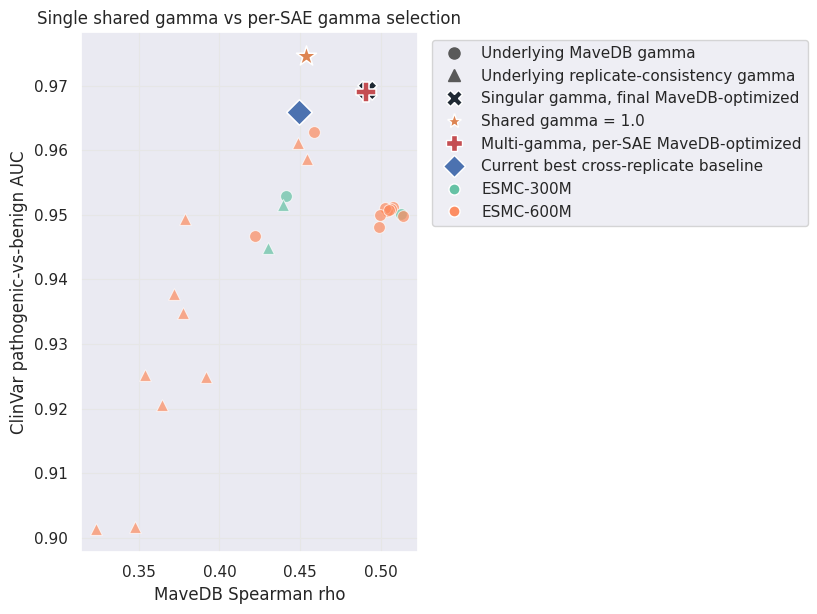

Single-vs-multi gamma figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_mavedb_spearman_top12_single_vs_multi_gamma_mavedb_auc.png


In [22]:
if per_sae_gamma_metrics_df.empty or ensemble_gamma_comparison_df.empty:
    print(f"No complete per-SAE gamma sweep outputs yet. Run or wait for: sbatch {PER_SAE_GAMMA_SCRIPT_PATH}")
else:
    underlying_plot_df = per_sae_gamma_selected_df.copy()
    underlying_plot_df["plot_group"] = underlying_plot_df["selection_objective"].map(
        {
            "per_source_mavedb_spearman": "Underlying SAE: MaveDB-optimized gamma",
            "per_source_replicate_consistency": "Underlying SAE: replicate-consistency gamma",
        }
    )
    ensemble_plot_df = ensemble_gamma_comparison_df.copy()
    ensemble_plot_df["plot_group"] = ensemble_plot_df["method_label"]

    fig, ax = plt.subplots(figsize=(8.4, 6.3))
    source_palette = dict(
        zip(
            sorted(underlying_plot_df["model_short"].dropna().unique()),
            sns.color_palette("Set2", n_colors=underlying_plot_df["model_short"].nunique()),
        )
    )
    source_markers = {
        "per_source_mavedb_spearman": "o",
        "per_source_replicate_consistency": "^",
    }
    for (_, row) in underlying_plot_df.iterrows():
        ax.scatter(
            row["spearman_rho"],
            row["auc"],
            marker=source_markers.get(row["selection_objective"], "o"),
            s=72,
            color=source_palette.get(row["model_short"], "0.55"),
            edgecolor="white",
            linewidth=0.7,
            alpha=0.72,
        )

    ensemble_marker_specs = {
        "Singular gamma, final MaveDB-optimized": {"marker": "X", "color": "#1f2933", "size": 190},
        "Shared gamma = 1.0": {"marker": "*", "color": "#dd8452", "size": 230},
        "Multi-gamma, per-SAE MaveDB-optimized": {"marker": "P", "color": "#c44e52", "size": 190},
        "Current best cross-replicate baseline": {"marker": "D", "color": "#4c72b0", "size": 170},
    }
    for _, row in ensemble_plot_df.iterrows():
        spec = ensemble_marker_specs.get(row["method_label"], {"marker": "s", "color": "black", "size": 160})
        ax.scatter(
            row["spearman_rho"],
            row["auc"],
            marker=spec["marker"],
            s=spec["size"],
            color=spec["color"],
            edgecolor="white",
            linewidth=1.1,
            zorder=5,
            label=row["method_label"],
        )

    source_handles = []
    for model_short, color in source_palette.items():
        source_handles.append(plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markeredgecolor="white", markersize=8, label=model_short))
    objective_handles = [
        plt.Line2D([0], [0], marker="o", color="0.35", linestyle="none", markersize=8, label="Underlying MaveDB gamma"),
        plt.Line2D([0], [0], marker="^", color="0.35", linestyle="none", markersize=8, label="Underlying replicate-consistency gamma"),
    ]
    ensemble_handles = [
        plt.Line2D([0], [0], marker=spec["marker"], color="none", markerfacecolor=spec["color"], markeredgecolor="white", markersize=11, label=label)
        for label, spec in ensemble_marker_specs.items()
    ]
    handles = objective_handles + ensemble_handles + source_handles
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
    ax.set_xlabel("MaveDB Spearman rho")
    ax.set_ylabel("ClinVar pathogenic-vs-benign AUC")
    ax.set_title("Single shared gamma vs per-SAE gamma selection")
    ax.grid(color="0.90", linewidth=0.8)
    fig.tight_layout()

    single_vs_multi_gamma_figure_path = paths.figure_dir / "BRCA1_best_mavedb_spearman_top12_single_vs_multi_gamma_mavedb_auc.png"
    fig.savefig(single_vs_multi_gamma_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    print(f"Single-vs-multi gamma figure: {single_vs_multi_gamma_figure_path}")


## Overall Takeaways

This final section builds a compact 0-3 review-star comparison for the main baselines, the best raw ESM embedding, the best single SAE, and the best normal SAE ensemble. It also adds one gamma=1 companion point for the SAE ensemble.


In [23]:
OVERALL_TAKEAWAY_THRESHOLDS = [0, 1, 2, 3]
OVERALL_TAKEAWAY_GAMMA = 1.0
OVERALL_TAKEAWAY_DIR = OUTPUT_ROOT / "overall_takeaways"
OVERALL_TAKEAWAY_DIR.mkdir(parents=True, exist_ok=True)

# Reconstruct these paths if this final section is run in a fresh kernel after the earlier config cells.
if "PER_SAE_GAMMA_COLLECTION" not in globals():
    PER_SAE_GAMMA_COLLECTION = f"best_mavedb_spearman_top{COLLECTION_TOP_N}"
if "PER_SAE_GAMMA_AGGREGATION" not in globals():
    PER_SAE_GAMMA_AGGREGATION = "rank_worst"
if "PER_SAE_GAMMA_RUN_NAME" not in globals():
    PER_SAE_GAMMA_RUN_NAME = f"{PER_SAE_GAMMA_COLLECTION}_{PER_SAE_GAMMA_AGGREGATION}_per_sae_gamma_sweep"
if "PER_SAE_GAMMA_OUTPUT_DIR" not in globals():
    PER_SAE_GAMMA_OUTPUT_DIR = OUTPUT_ROOT / PER_SAE_GAMMA_RUN_NAME
if "PER_SAE_GAMMA_SCRIPT_PATH" not in globals():
    PER_SAE_GAMMA_SCRIPT_PATH = JOB_ROOT / f"submit_{PER_SAE_GAMMA_RUN_NAME}.sh"
if "per_sae_gamma_source_rows" not in globals():
    per_sae_gamma_source_rows = collections[PER_SAE_GAMMA_COLLECTION].copy().reset_index(drop=True)

overall_source_metrics_df = h.load_metrics_table(paths.spearman_auc_table_path)
overall_ensemble_summary_path = paths.table_dir / "BRCA1_esmc_sae_layer_ensemble_performance_summary.csv"
assert overall_ensemble_summary_path.is_file(), f"Missing ensemble summary: {overall_ensemble_summary_path}"
overall_ensemble_summary_df = pd.read_csv(overall_ensemble_summary_path)

def _best_existing_row(mask, sort_cols=("spearman_rho", "auc"), ascending=(False, False), label="row"):
    candidates = overall_source_metrics_df[mask].copy()
    assert not candidates.empty, f"No candidates found for {label}."
    for col in sort_cols:
        candidates[col] = pd.to_numeric(candidates[col], errors="coerce")
    return candidates.sort_values(list(sort_cols), ascending=list(ascending)).iloc[0]

regular_popdms_row = _best_existing_row(overall_source_metrics_df["benchmark"].eq("Regular popDMS"), label="regular popDMS")
enrichment_ratio_row = _best_existing_row(overall_source_metrics_df["benchmark"].eq("Enrichment ratio"), label="enrichment ratio")
best_esm_row = _best_existing_row(overall_source_metrics_df["benchmark"].eq("Raw embeddings"), label="raw ESM embedding")
best_sae_row = _best_existing_row(overall_source_metrics_df["benchmark"].astype(str).str.contains("Fixed DeltaEmbSAE", na=False), label="single SAE")

rank_ensemble_candidates = overall_ensemble_summary_df[
    overall_ensemble_summary_df["aggregation"].isin(["rank_worst", "rank_median", "rank_best"])
].copy()
assert not rank_ensemble_candidates.empty, "No normal rank-ensemble SAE candidates were found."
for col in ["spearman_auc_rank_score", "mavedb_spearman_rank", "auc_all_binary_rank"]:
    if col in rank_ensemble_candidates.columns:
        rank_ensemble_candidates[col] = pd.to_numeric(rank_ensemble_candidates[col], errors="coerce")
if "spearman_auc_rank_score" in rank_ensemble_candidates.columns:
    best_ensemble_row = rank_ensemble_candidates.sort_values(
        ["spearman_auc_rank_score", "mavedb_spearman_rank", "auc_all_binary_rank"],
        ascending=[True, True, True],
    ).iloc[0]
else:
    best_ensemble_row = rank_ensemble_candidates.sort_values("mavedb_spearman", ascending=False).iloc[0]

print("Selected normal points:")
for name, row in [
    ("Regular popDMS", regular_popdms_row),
    ("Enrichment ratio", enrichment_ratio_row),
    ("Best raw ESM", best_esm_row),
    ("Best single SAE", best_sae_row),
]:
    print(f"- {name}: {row['model_label']}")
print(f"- Best normal SAE ensemble: {best_ensemble_row['method_label']}")

def _read_fitness_path(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"Missing fitness table: {path}")
    out = pd.read_csv(path)[["SequenceIndex", "fitness"]].copy()
    out["SequenceIndex"] = out["SequenceIndex"].astype(str)
    out["fitness"] = pd.to_numeric(out["fitness"], errors="coerce")
    return out

def _per_sae_gamma_one_metric_row(source_idx):
    metric_paths = sorted(PER_SAE_GAMMA_OUTPUT_DIR.glob(f"source_{int(source_idx):02d}_*/*_gamma_metrics.csv"))
    if not metric_paths:
        raise FileNotFoundError(f"Missing per-SAE gamma metrics for source_idx={source_idx}.")
    metrics_df = pd.read_csv(metric_paths[0])
    metrics_df["gamma"] = pd.to_numeric(metrics_df["gamma"], errors="coerce")
    selected = metrics_df[np.isclose(metrics_df["gamma"], OVERALL_TAKEAWAY_GAMMA)].copy()
    if selected.empty:
        raise FileNotFoundError(f"Per-SAE source_idx={source_idx} does not yet include gamma={OVERALL_TAKEAWAY_GAMMA:g}. Wait for {PER_SAE_GAMMA_SCRIPT_PATH} to finish.")
    return selected.iloc[0]

def _per_sae_gamma_one_fitness(source_idx):
    row = _per_sae_gamma_one_metric_row(source_idx)
    fitness_path = Path(row["fitness_table_path"])
    table = pd.read_csv(fitness_path)
    table["gamma"] = pd.to_numeric(table["gamma"], errors="coerce")
    table = table[np.isclose(table["gamma"], OVERALL_TAKEAWAY_GAMMA)].copy()
    if table.empty:
        raise FileNotFoundError(f"Missing gamma={OVERALL_TAKEAWAY_GAMMA:g} fitness rows in {fitness_path}")
    return table[["SequenceIndex", "fitness"]].assign(SequenceIndex=lambda df: df["SequenceIndex"].astype(str))

def _per_sae_gamma_one_ensemble_fitness():
    missing = []
    series = []
    for source_idx, source_row in per_sae_gamma_source_rows.reset_index(drop=True).iterrows():
        try:
            fitness_df = _per_sae_gamma_one_fitness(source_idx)
        except FileNotFoundError as exc:
            missing.append(str(exc))
            continue
        name = f"{source_row['model_short']}_L{int(float(source_row['layer']))}"
        series.append(pd.Series(fitness_df["fitness"].to_numpy(dtype=float), index=fitness_df["SequenceIndex"].astype(str), name=name))
    if missing:
        raise FileNotFoundError("\n".join(missing))
    score_matrix = pd.concat(series, axis=1)
    return h.rank_ensemble_fitness_from_score_matrix(score_matrix, aggregation=str(best_ensemble_row["aggregation"]))[["SequenceIndex", "fitness"]]

overall_takeaway_cache_paths = {
    "best_ensemble_gamma1": OVERALL_TAKEAWAY_DIR / "BRCA1_best_sae_ensemble_gamma_1_fitness.csv",
}

overall_takeaway_specs = [
    {
        "method_family": "Regular popDMS",
        "point_mode": "normal",
        "plot_label": "Regular popDMS",
        "fitness_df": _read_fitness_path(regular_popdms_row["fitness_path"]),
        "gamma_note": "existing popDMS baseline",
    },
    {
        "method_family": "Enrichment ratio",
        "point_mode": "normal",
        "plot_label": "Enrichment ratio",
        "fitness_df": _read_fitness_path(enrichment_ratio_row["fitness_path"]),
        "gamma_note": "no gamma parameter",
    },
    {
        "method_family": "Best raw ESM",
        "point_mode": "normal",
        "plot_label": str(best_esm_row["model_label"]),
        "fitness_df": _read_fitness_path(best_esm_row["fitness_path"]),
        "gamma_note": "replicate-consistency gamma",
    },
    {
        "method_family": "Best single SAE",
        "point_mode": "normal",
        "plot_label": str(best_sae_row["model_label"]),
        "fitness_df": _read_fitness_path(best_sae_row["fitness_path"]),
        "gamma_note": "replicate-consistency gamma",
    },
    {
        "method_family": "Best SAE ensemble",
        "point_mode": "normal",
        "plot_label": str(best_ensemble_row["method_label"]),
        "fitness_df": _read_fitness_path(best_ensemble_row["fitness_path"]),
        "gamma_note": "source replicate-consistency gammas",
    },
]

overall_takeaway_missing = []
try:
    best_ensemble_gamma1_fitness_df = _per_sae_gamma_one_ensemble_fitness()
    best_ensemble_gamma1_fitness_df.to_csv(overall_takeaway_cache_paths["best_ensemble_gamma1"], index=False)
    overall_takeaway_specs.append(
        {
            "method_family": "Best SAE ensemble",
            "point_mode": "gamma=1",
            "plot_label": str(best_ensemble_row["method_label"]),
            "fitness_df": best_ensemble_gamma1_fitness_df,
            "gamma_note": "all source gammas fixed to 1",
        }
    )
except Exception as exc:
    overall_takeaway_missing.append(f"Best SAE ensemble gamma=1: {exc}")

rows = []
functional_auc_rows = []
for min_review_stars in OVERALL_TAKEAWAY_THRESHOLDS:
    review_filter = h.review_star_label(min_review_stars)
    annotation_map = h.clinvar_binary_annotation_map(
        paths.clinvar_annotation_cache_path,
        primary_key="hgvs_nt",
        min_review_stars=min_review_stars,
    )
    functional_fitness_df = h.functional_score_fitness_dataframe(runner.scores_dataframe, annotation_map)
    functional_auc = h.classification_metrics_for_fitness(functional_fitness_df)["auc"]
    functional_auc_rows.append(
        {
            "min_review_stars": min_review_stars,
            "review_filter": review_filter,
            "functional_score_auc": functional_auc,
        }
    )
    for spec in overall_takeaway_specs:
        fitness_df = spec["fitness_df"][["SequenceIndex", "fitness"]].copy()
        fitness_df["SequenceIndex"] = fitness_df["SequenceIndex"].astype(str)
        fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map)
        spearman_rho, n_score_sequences = h.spearman_for_fitness_dataframe(fitness_df, runner.scores_dataframe, score_col="score")
        auc_metrics = h.classification_metrics_for_fitness(fitness_df)
        rows.append(
            {
                "min_review_stars": min_review_stars,
                "review_filter": review_filter,
                "method_family": spec["method_family"],
                "point_mode": spec["point_mode"],
                "plot_label": spec["plot_label"],
                "gamma_note": spec["gamma_note"],
                "spearman_rho": spearman_rho,
                "auc": auc_metrics["auc"],
                "functional_score_auc": functional_auc,
                "n_score_sequences": n_score_sequences,
                **auc_metrics,
            }
        )

overall_takeaway_plot_df = pd.DataFrame(rows)
overall_takeaway_functional_auc_df = pd.DataFrame(functional_auc_rows)
overall_takeaway_rows_path = paths.table_dir / "BRCA1_overall_takeaways_mavedb_auc_rows.csv"
overall_takeaway_plot_df.to_csv(overall_takeaway_rows_path, index=False)

if overall_takeaway_missing:
    print("Some gamma=1 points are not ready yet. The normal and available gamma=1 rows were still written.")
    for message in overall_takeaway_missing:
        print(f"- {message}")
    print(f"If this is due to per-SAE outputs, wait for or rerun: sbatch {PER_SAE_GAMMA_SCRIPT_PATH}")
print(f"Overall takeaways rows: {overall_takeaway_rows_path}")
display(
    overall_takeaway_plot_df[
        ["review_filter", "method_family", "point_mode", "spearman_rho", "auc", "functional_score_auc", "gamma_note"]
    ].assign(
        spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
        functional_score_auc=lambda df: pd.to_numeric(df["functional_score_auc"], errors="coerce").round(3),
    )
)


Selected normal points:
- Regular popDMS: Regular popDMS
- Enrichment ratio: Enrichment ratio
- Best raw ESM: ESMC-300M Layer_30 raw max_pool
- Best single SAE: ESMC-600M Layer_36 DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42
- Best normal SAE ensemble: best mavedb spearman top 12 worst rank


Overall takeaways rows: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_overall_takeaways_mavedb_auc_rows.csv


,review_filter,method_family,point_mode,spearman_rho,auc,functional_score_auc,gamma_note
0,all binary annotations,Regular popDMS,normal,0.565,0.933,0.989,existing popDMS baseline
1,all binary annotations,Enrichment ratio,normal,0.635,0.920,0.989,no gamma parameter
2,all binary annotations,Best raw ESM,normal,0.430,0.953,0.989,replicate-consistency gamma
3,all binary annotations,Best single SAE,normal,0.449,0.961,0.989,replicate-consistency gamma
4,all binary annotations,Best SAE ensemble,normal,0.449,0.966,0.989,source replicate-consistency gammas
5,all binary annotations,Best SAE ensemble,gamma=1,0.454,0.975,0.989,all source gammas fixed to 1
6,>= 1 star(s),Regular popDMS,normal,0.565,0.945,0.991,existing popDMS baseline
7,>= 1 star(s),Enrichment ratio,normal,0.635,0.923,0.991,no gamma parameter
8,>= 1 star(s),Best raw ESM,normal,0.430,0.954,0.991,replicate-consistency gamma
9,>= 1 star(s),Best single SAE,normal,0.449,0.968,0.991,replicate-consistency gamma


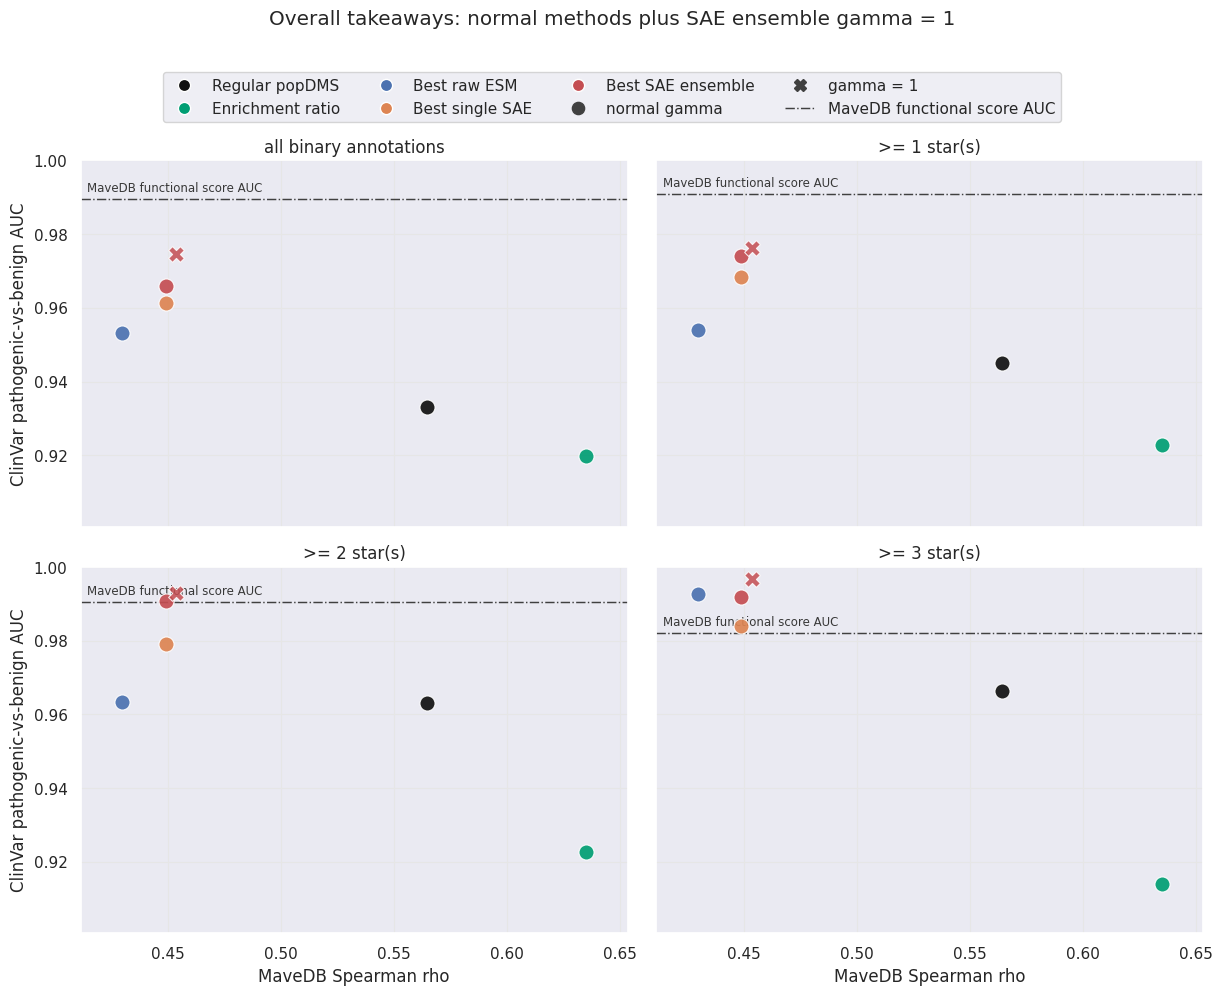

Overall takeaways figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_overall_takeaways_mavedb_vs_auc_0_to_3_stars.png


In [24]:
if overall_takeaway_plot_df.empty:
    print("No overall takeaway rows are available yet.")
else:
    plot_df = overall_takeaway_plot_df[
        overall_takeaway_plot_df["min_review_stars"].isin(OVERALL_TAKEAWAY_THRESHOLDS)
        & np.isfinite(pd.to_numeric(overall_takeaway_plot_df["spearman_rho"], errors="coerce"))
        & np.isfinite(pd.to_numeric(overall_takeaway_plot_df["auc"], errors="coerce"))
    ].copy()
    plot_df["spearman_rho"] = pd.to_numeric(plot_df["spearman_rho"], errors="coerce")
    plot_df["auc"] = pd.to_numeric(plot_df["auc"], errors="coerce")
    family_order = ["Regular popDMS", "Enrichment ratio", "Best raw ESM", "Best single SAE", "Best SAE ensemble"]
    family_palette = {
        "Regular popDMS": "#111111",
        "Enrichment ratio": "#009e73",
        "Best raw ESM": "#4c72b0",
        "Best single SAE": "#dd8452",
        "Best SAE ensemble": "#c44e52",
    }
    mode_specs = {
        "normal": {"marker": "o", "label": "normal gamma", "face": True, "size": 118, "alpha": 0.92},
        "gamma=1": {"marker": "X", "label": "gamma = 1", "face": True, "size": 128, "alpha": 0.86},
    }

    x_values = plot_df["spearman_rho"].to_numpy(dtype=float)
    y_values = np.concatenate(
        [
            plot_df["auc"].to_numpy(dtype=float),
            overall_takeaway_functional_auc_df["functional_score_auc"].dropna().to_numpy(dtype=float),
        ]
    )
    x_range = np.nanmax(x_values) - np.nanmin(x_values)
    y_range = np.nanmax(y_values) - np.nanmin(y_values)
    x_pad = max(0.012, 0.09 * x_range)
    y_pad = max(0.006, 0.16 * y_range)
    xlim = (max(-1.0, np.nanmin(x_values) - x_pad), min(1.0, np.nanmax(x_values) + x_pad))
    ylim = (max(0.0, np.nanmin(y_values) - y_pad), min(1.0, np.nanmax(y_values) + y_pad))

    fig, axes = plt.subplots(2, 2, figsize=(12.4, 9.2), sharex=True, sharey=True)
    axes_flat = axes.ravel()
    for ax, min_review_stars in zip(axes_flat, OVERALL_TAKEAWAY_THRESHOLDS):
        panel_df = plot_df[plot_df["min_review_stars"].eq(min_review_stars)].copy()
        review_filter = h.review_star_label(min_review_stars)
        functional_auc = overall_takeaway_functional_auc_df.loc[
            overall_takeaway_functional_auc_df["min_review_stars"].eq(min_review_stars),
            "functional_score_auc",
        ]
        if not functional_auc.empty and np.isfinite(functional_auc.iloc[0]):
            ax.axhline(
                float(functional_auc.iloc[0]),
                color="0.25",
                linestyle="-.",
                linewidth=1.05,
                zorder=1,
            )
            ax.text(
                xlim[0] + 0.012 * (xlim[1] - xlim[0]),
                float(functional_auc.iloc[0]) + 0.012 * (ylim[1] - ylim[0]),
                "MaveDB functional score AUC",
                fontsize=8.5,
                color="0.22",
                va="bottom",
            )
        for family in family_order:
            family_df = panel_df[panel_df["method_family"].eq(family)]
            for mode, mode_df in family_df.groupby("point_mode", sort=False):
                spec = mode_specs.get(mode, mode_specs["normal"])
                ax.scatter(
                    mode_df["spearman_rho"],
                    mode_df["auc"],
                    marker=spec["marker"],
                    s=spec["size"],
                    color=family_palette.get(family, "0.4"),
                    edgecolor="white",
                    linewidth=0.8,
                    alpha=spec["alpha"],
                    zorder=4 if mode == "gamma=1" else 3,
                )
        ax.set_title(review_filter)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(color="0.90", linewidth=0.75)
    for ax in axes[:, 0]:
        ax.set_ylabel("ClinVar pathogenic-vs-benign AUC")
    for ax in axes[-1, :]:
        ax.set_xlabel("MaveDB Spearman rho")

    family_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=family_palette[family], markeredgecolor="white", markersize=8.8, label=family)
        for family in family_order
    ]
    mode_handles = [
        plt.Line2D([0], [0], marker=mode_specs[mode]["marker"], linestyle="none", color="0.25", markersize=8.8, label=mode_specs[mode]["label"])
        for mode in ["normal", "gamma=1"]
    ]
    line_handle = plt.Line2D([0], [0], color="0.25", linestyle="-.", linewidth=1.05, label="MaveDB functional score AUC")
    fig.legend(
        handles=family_handles + mode_handles + [line_handle],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=4,
        frameon=True,
    )
    fig.suptitle("Overall takeaways: normal methods plus SAE ensemble gamma = 1", y=1.08)
    fig.tight_layout()
    overall_takeaway_figure_path = paths.figure_dir / "BRCA1_overall_takeaways_mavedb_vs_auc_0_to_3_stars.png"
    fig.savefig(overall_takeaway_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    print(f"Overall takeaways figure: {overall_takeaway_figure_path}")


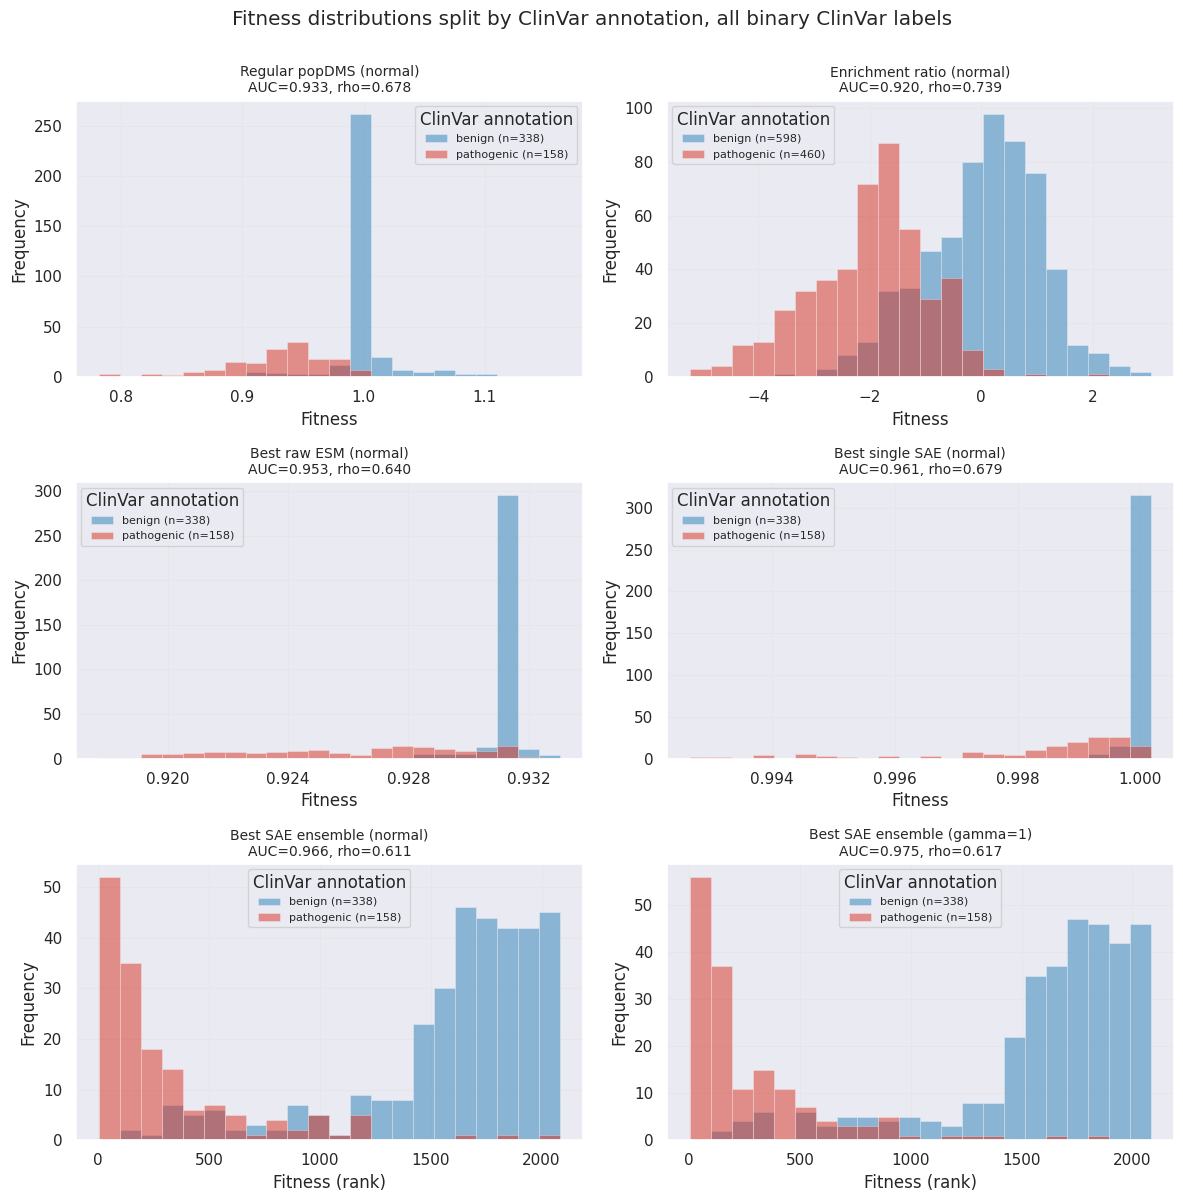

Overall-takeaway fitness distribution summary: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_overall_takeaways_fitness_distribution_summary.csv
Overall-takeaway fitness distribution figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_overall_takeaways_fitness_distributions_by_clinvar.png


,component,n_variants_selected,source_idx,model_short,layer,gamma,spearman_rho_gamma1,auc_gamma1,mean_pairwise_pearson_r_gamma1,spearman_rho_gamma1_rank,fraction
0,ESMC-600M_L32,508,3,ESMC-600M,32.0,1.0,0.393,0.934,0.889,7.0,0.241
1,ESMC-300M_L30,269,1,ESMC-300M,30.0,1.0,0.439,0.952,0.964,5.0,0.128
2,ESMC-600M_L17,232,11,ESMC-600M,17.0,1.0,0.362,0.921,0.927,11.0,0.110
3,ESMC-600M_L36,221,0,ESMC-600M,36.0,1.0,0.449,0.961,0.952,4.0,0.105
4,ESMC-600M_L13,195,10,ESMC-600M,13.0,1.0,0.332,0.904,0.953,12.0,0.093
5,ESMC-600M_L33,140,5,ESMC-600M,33.0,1.0,0.402,0.935,0.879,6.0,0.067
6,ESMC-600M_L35,132,6,ESMC-600M,35.0,1.0,0.489,0.954,0.828,1.0,0.063
7,ESMC-300M_L29,124,4,ESMC-300M,29.0,1.0,0.464,0.946,0.824,2.0,0.059
8,ESMC-600M_L34,102,2,ESMC-600M,34.0,1.0,0.452,0.940,0.845,3.0,0.048
9,ESMC-600M_L29,86,9,ESMC-600M,29.0,1.0,0.362,0.938,0.909,10.0,0.041


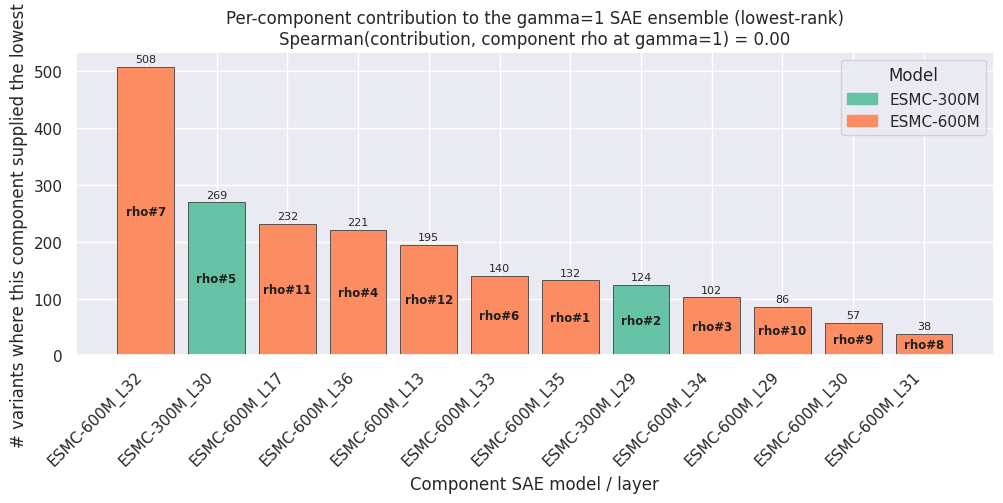

Gamma=1 ensemble component contribution table: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_sae_ensemble_gamma1_component_contributions.csv
Gamma=1 ensemble component contribution figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_sae_ensemble_gamma1_component_contributions.png


In [25]:
# Overall-takeaway fitness distributions and gamma=1 ensemble component contributions.
# Run the Overall Takeaways preparation cell immediately above first.
if "overall_takeaway_specs" not in globals():
    raise RuntimeError("Run the Overall Takeaways preparation cell before this plotting cell.")
if "best_ensemble_row" not in globals():
    raise RuntimeError("Run the Overall Takeaways preparation cell so best_ensemble_row is defined.")

annotation_map_all_binary = h.clinvar_binary_annotation_map(
    paths.clinvar_annotation_cache_path,
    primary_key="hgvs_nt",
    min_review_stars=0,
)
pathogenicity_palette = {"benign": "#2c7fb8", "pathogenic": "#d7301f"}

# 1) Fitness distributions for every point family/mode shown in the final MaveDB-vs-AUC plot.
distribution_specs = []
for spec in overall_takeaway_specs:
    fitness_df = spec["fitness_df"][["SequenceIndex", "fitness"]].copy()
    fitness_df["SequenceIndex"] = fitness_df["SequenceIndex"].astype(str)
    fitness_df["fitness"] = pd.to_numeric(fitness_df["fitness"], errors="coerce")
    fitness_df["annotation"] = fitness_df["SequenceIndex"].map(annotation_map_all_binary)
    fitness_df = fitness_df[
        fitness_df["annotation"].isin(["benign", "pathogenic"])
        & np.isfinite(fitness_df["fitness"])
    ].copy()
    if fitness_df.empty:
        continue
    distribution_specs.append({**spec, "fitness_df": fitness_df})

if not distribution_specs:
    print("No fitness distributions were available for the overall-takeaway methods.")
else:
    ncols = 2
    nrows = int(np.ceil(len(distribution_specs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.0 * ncols, 4.0 * nrows), squeeze=False)
    axes_flat = axes.ravel()
    distribution_summary_rows = []
    for ax, spec in zip(axes_flat, distribution_specs):
        fitness_df = spec["fitness_df"].copy()
        finite_values = fitness_df["fitness"].to_numpy(dtype=float)
        if np.nanmin(finite_values) == np.nanmax(finite_values):
            center = float(np.nanmin(finite_values))
            bin_edges = np.array([center - 0.5, center + 0.5])
        else:
            bin_edges = np.histogram_bin_edges(finite_values, bins=min(22, max(8, int(np.sqrt(len(finite_values))))))
        for annotation in ["benign", "pathogenic"]:
            values = fitness_df.loc[fitness_df["annotation"].eq(annotation), "fitness"].to_numpy(dtype=float)
            ax.hist(
                values,
                bins=bin_edges,
                color=pathogenicity_palette[annotation],
                alpha=0.5,
                label=f"{annotation} (n={len(values)})",
                edgecolor="white",
                linewidth=0.4,
            )
        auc_metric = h.classification_metrics_for_fitness(fitness_df)["auc"]
        rho_metric, n_score_sequences = h.spearman_for_fitness_dataframe(fitness_df, runner.scores_dataframe, score_col="score")
        distribution_summary_rows.append(
            {
                "method_family": spec["method_family"],
                "point_mode": spec["point_mode"],
                "plot_label": spec["plot_label"],
                "gamma_note": spec["gamma_note"],
                "spearman_rho": rho_metric,
                "auc_all_binary": auc_metric,
                "n_score_sequences": n_score_sequences,
                "n_benign": int(fitness_df["annotation"].eq("benign").sum()),
                "n_pathogenic": int(fitness_df["annotation"].eq("pathogenic").sum()),
            }
        )
        mode_label = "gamma=1" if spec["point_mode"] == "gamma=1" else "normal"
        ax.set_title(f"{spec['method_family']} ({mode_label})\nAUC={auc_metric:.3f}, rho={rho_metric:.3f}", fontsize=10)
        ax.set_xlabel("Fitness (rank)" if spec["method_family"] == "Best SAE ensemble" else "Fitness")
        ax.set_ylabel("Frequency")
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5, prune="both"))
        ax.grid(color="0.90", linewidth=0.65)
        ax.legend(title="ClinVar annotation", fontsize=8)
    for ax in axes_flat[len(distribution_specs):]:
        ax.axis("off")
    fig.suptitle("Fitness distributions split by ClinVar annotation, all binary ClinVar labels", y=1.0)
    fig.tight_layout()
    distribution_figure_path = paths.figure_dir / "BRCA1_overall_takeaways_fitness_distributions_by_clinvar.png"
    fig.savefig(distribution_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()

    distribution_summary_df = pd.DataFrame(distribution_summary_rows)
    distribution_summary_path = paths.table_dir / "BRCA1_overall_takeaways_fitness_distribution_summary.csv"
    distribution_summary_df.to_csv(distribution_summary_path, index=False)
    print(f"Overall-takeaway fitness distribution summary: {distribution_summary_path}")
    print(f"Overall-takeaway fitness distribution figure: {distribution_figure_path}")

# 2) Per-component contribution for the best SAE ensemble when every component uses gamma=1.
def _overall_gamma1_metric_row(source_idx):
    metric_paths = sorted(PER_SAE_GAMMA_OUTPUT_DIR.glob(f"source_{int(source_idx):02d}_*/*_gamma_metrics.csv"))
    if not metric_paths:
        raise FileNotFoundError(f"Missing per-SAE gamma metrics for source_idx={source_idx}.")
    metrics_df = pd.read_csv(metric_paths[0])
    metrics_df["gamma"] = pd.to_numeric(metrics_df["gamma"], errors="coerce")
    selected = metrics_df[np.isclose(metrics_df["gamma"], OVERALL_TAKEAWAY_GAMMA)].copy()
    if selected.empty:
        raise FileNotFoundError(f"Missing gamma={OVERALL_TAKEAWAY_GAMMA:g} metrics for source_idx={source_idx}.")
    return selected.iloc[0]

def _overall_gamma1_fitness_series(source_idx, source_row):
    metric_row = _overall_gamma1_metric_row(source_idx)
    fitness_path = Path(metric_row["fitness_table_path"])
    fitness_df = pd.read_csv(fitness_path)
    fitness_df["gamma"] = pd.to_numeric(fitness_df["gamma"], errors="coerce")
    fitness_df = fitness_df[np.isclose(fitness_df["gamma"], OVERALL_TAKEAWAY_GAMMA)].copy()
    if fitness_df.empty:
        raise FileNotFoundError(f"Missing gamma={OVERALL_TAKEAWAY_GAMMA:g} fitness rows in {fitness_path}.")
    component = f"{source_row['model_short']}_L{int(float(source_row['layer']))}"
    return pd.Series(
        pd.to_numeric(fitness_df["fitness"], errors="coerce").to_numpy(dtype=float),
        index=fitness_df["SequenceIndex"].astype(str),
        name=component,
    ), metric_row

component_series = []
component_metric_rows = []
for source_idx, source_row in per_sae_gamma_source_rows.reset_index(drop=True).iterrows():
    series, metric_row = _overall_gamma1_fitness_series(source_idx, source_row)
    component_series.append(series)
    component_metric_rows.append(
        {
            "source_idx": int(source_idx),
            "component": series.name,
            "model_short": source_row.get("model_short", ""),
            "layer": source_row.get("layer", np.nan),
            "gamma": float(metric_row["gamma"]),
            "spearman_rho_gamma1": float(metric_row["spearman_rho"]),
            "auc_gamma1": float(metric_row["auc"]),
            "mean_pairwise_pearson_r_gamma1": float(metric_row["mean_pairwise_pearson_r"]),
        }
    )

component_score_matrix = pd.concat(component_series, axis=1)
component_rank_matrix = component_score_matrix.rank(method="average", ascending=True)
valid_variants = component_rank_matrix.notna().any(axis=1)
ensemble_aggregation = str(best_ensemble_row.get("aggregation", "rank_worst"))
if ensemble_aggregation in {"rank_worst", "worst_rank"}:
    selection_word = "lowest"
    selected_component = component_rank_matrix.loc[valid_variants].idxmin(axis=1)
elif ensemble_aggregation in {"rank_best", "best_rank"}:
    selection_word = "highest"
    selected_component = component_rank_matrix.loc[valid_variants].idxmax(axis=1)
elif ensemble_aggregation in {"rank_median", "median_rank"}:
    selection_word = "median-nearest"
    median_rank = component_rank_matrix.loc[valid_variants].median(axis=1)
    selected_component = component_rank_matrix.loc[valid_variants].sub(median_rank, axis=0).abs().idxmin(axis=1)
else:
    raise ValueError(f"Unsupported ensemble aggregation for contribution plot: {ensemble_aggregation}")

component_metrics_df = pd.DataFrame(component_metric_rows)
component_metrics_df["spearman_rho_gamma1_rank"] = component_metrics_df["spearman_rho_gamma1"].rank(
    ascending=False,
    method="min",
)
component_contribution_gamma1_df = (
    selected_component.value_counts()
    .reindex(component_score_matrix.columns, fill_value=0)
    .rename_axis("component")
    .reset_index(name="n_variants_selected")
    .merge(component_metrics_df, on="component", how="left")
)
component_contribution_gamma1_df["fraction"] = (
    component_contribution_gamma1_df["n_variants_selected"]
    / component_contribution_gamma1_df["n_variants_selected"].sum()
)
component_contribution_gamma1_df = component_contribution_gamma1_df.sort_values(
    "n_variants_selected",
    ascending=False,
).reset_index(drop=True)
contribution_corr_input = component_contribution_gamma1_df[["n_variants_selected", "spearman_rho_gamma1"]].dropna()
contribution_vs_rho_gamma1 = (
    contribution_corr_input["n_variants_selected"].corr(contribution_corr_input["spearman_rho_gamma1"], method="spearman")
    if len(contribution_corr_input) >= 3
    else np.nan
)
component_contribution_gamma1_path = paths.table_dir / "BRCA1_best_sae_ensemble_gamma1_component_contributions.csv"
component_contribution_gamma1_df.to_csv(component_contribution_gamma1_path, index=False)

display(
    component_contribution_gamma1_df.assign(
        fraction=lambda d: d["fraction"].round(3),
        spearman_rho_gamma1=lambda d: d["spearman_rho_gamma1"].round(3),
        auc_gamma1=lambda d: d["auc_gamma1"].round(3),
        mean_pairwise_pearson_r_gamma1=lambda d: d["mean_pairwise_pearson_r_gamma1"].round(3),
    )
)
family_palette = {
    short: color
    for short, color in zip(
        sorted(component_contribution_gamma1_df["model_short"].unique()),
        sns.color_palette("Set2", n_colors=component_contribution_gamma1_df["model_short"].nunique()),
    )
}
fig, ax = plt.subplots(figsize=(10.2, 5.2))
bars = ax.bar(
    component_contribution_gamma1_df["component"],
    component_contribution_gamma1_df["n_variants_selected"],
    color=component_contribution_gamma1_df["model_short"].map(family_palette),
    edgecolor="0.25",
    linewidth=0.6,
)
ax.bar_label(bars, padding=2, fontsize=8)
for bar, rho_rank in zip(bars, component_contribution_gamma1_df["spearman_rho_gamma1_rank"]):
    if pd.isna(rho_rank):
        continue
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"rho#{int(rho_rank)}",
        ha="center",
        va="center",
        fontsize=8.5,
        fontweight="bold",
        color="0.12",
    )
ax.set_xlabel("Component SAE model / layer")
ax.set_ylabel(f"# variants where this component supplied the {selection_word} rank")
ax.set_title(
    f"Per-component contribution to the gamma=1 SAE ensemble ({selection_word}-rank)\n"
    f"Spearman(contribution, component rho at gamma=1) = {contribution_vs_rho_gamma1:.2f}"
)
ax.tick_params(axis="x", rotation=45)
for tick_label in ax.get_xticklabels():
    tick_label.set_ha("right")
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=family_palette[short]) for short in family_palette]
ax.legend(legend_handles, list(family_palette), title="Model", loc="upper right")
fig.tight_layout()
component_contribution_gamma1_figure_path = paths.figure_dir / "BRCA1_best_sae_ensemble_gamma1_component_contributions.png"
fig.savefig(component_contribution_gamma1_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Gamma=1 ensemble component contribution table: {component_contribution_gamma1_path}")
print(f"Gamma=1 ensemble component contribution figure: {component_contribution_gamma1_figure_path}")


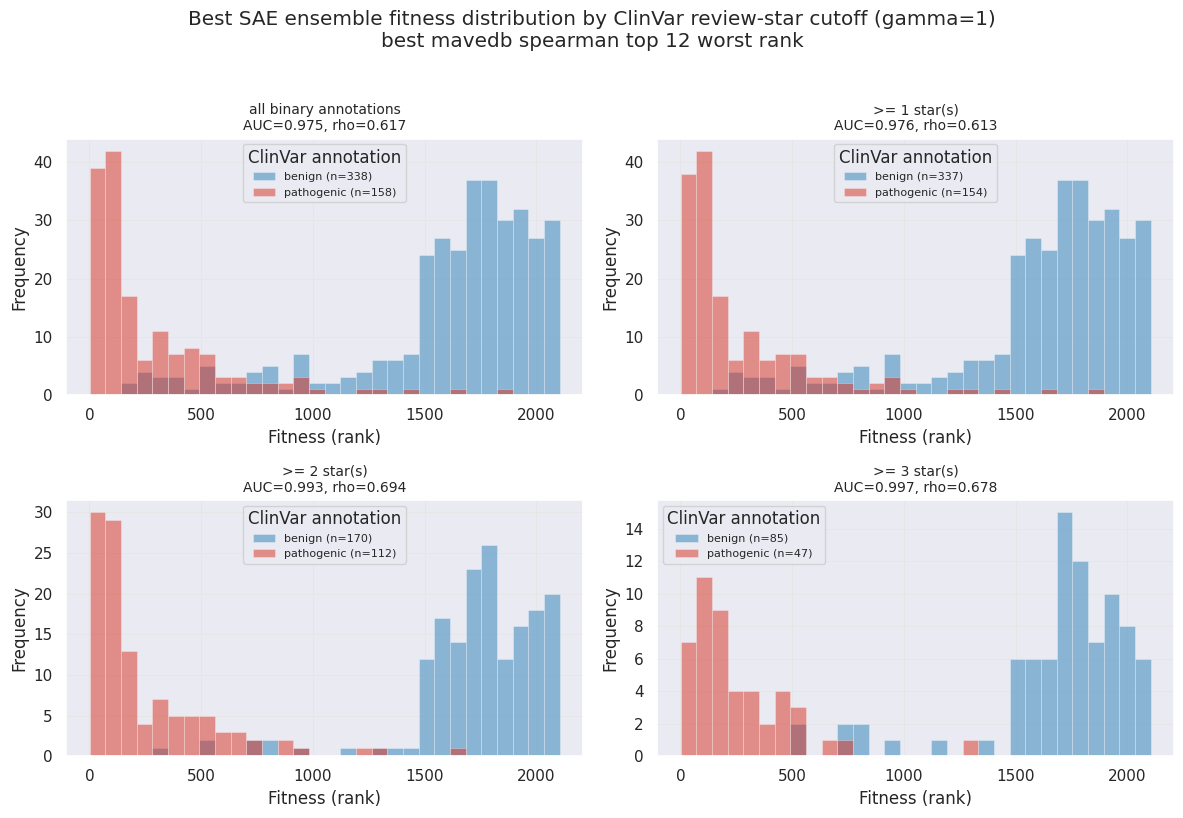

,min_review_stars,review_filter,point_mode,plot_label,auc,spearman_rho,n_score_sequences,n_benign,n_pathogenic,n_variants
0,0,all binary annotations,gamma=1,best mavedb spearman top 12 worst rank,0.975,0.617,496,338,158,496
1,1,>= 1 star(s),gamma=1,best mavedb spearman top 12 worst rank,0.976,0.613,491,337,154,491
2,2,>= 2 star(s),gamma=1,best mavedb spearman top 12 worst rank,0.993,0.694,282,170,112,282
3,3,>= 3 star(s),gamma=1,best mavedb spearman top 12 worst rank,0.997,0.678,132,85,47,132


Best SAE ensemble review-star summary: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_sae_ensemble_gamma_1_fitness_distribution_by_review_stars.csv
Best SAE ensemble review-star figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_sae_ensemble_gamma_1_fitness_distribution_by_review_stars.png


In [26]:
# Best SAE ensemble fitness distribution split by ClinVar annotation across review-star thresholds.
# Run the Overall Takeaways preparation cell first so `overall_takeaway_specs` is available.
if "overall_takeaway_specs" not in globals():
    raise RuntimeError("Run the Overall Takeaways preparation cell before this plotting cell.")

ensemble_specs = [
    spec for spec in overall_takeaway_specs
    if spec.get("method_family") == "Best SAE ensemble"
]
if not ensemble_specs:
    raise RuntimeError("No Best SAE ensemble spec was found in overall_takeaway_specs.")

preferred_specs = [spec for spec in ensemble_specs if spec.get("point_mode") == "gamma=1"]
if not preferred_specs:
    preferred_specs = [spec for spec in ensemble_specs if spec.get("point_mode") == "normal"]
best_ensemble_star_spec = preferred_specs[0]

best_ensemble_star_fitness_df = best_ensemble_star_spec["fitness_df"][["SequenceIndex", "fitness"]].copy()
best_ensemble_star_fitness_df["SequenceIndex"] = best_ensemble_star_fitness_df["SequenceIndex"].astype(str)
best_ensemble_star_fitness_df["fitness"] = pd.to_numeric(
    best_ensemble_star_fitness_df["fitness"],
    errors="coerce",
)
best_ensemble_star_fitness_df = best_ensemble_star_fitness_df.dropna(subset=["fitness"])

pathogenicity_palette = {"benign": "#2c7fb8", "pathogenic": "#d7301f"}
star_cutoffs = OVERALL_TAKEAWAY_THRESHOLDS if "OVERALL_TAKEAWAY_THRESHOLDS" in globals() else [0, 1, 2, 3]
star_panels = []
summary_rows = []
for min_review_stars in star_cutoffs:
    review_filter = h.review_star_label(min_review_stars)
    annotation_map = h.clinvar_binary_annotation_map(
        paths.clinvar_annotation_cache_path,
        primary_key="hgvs_nt",
        min_review_stars=min_review_stars,
    )
    panel_df = best_ensemble_star_fitness_df.copy()
    panel_df["annotation"] = panel_df["SequenceIndex"].map(annotation_map)
    panel_df = panel_df[
        panel_df["annotation"].isin(["benign", "pathogenic"])
        & np.isfinite(panel_df["fitness"])
    ].copy()
    if panel_df.empty:
        continue
    auc_metrics = h.classification_metrics_for_fitness(panel_df)
    spearman_rho, n_score_sequences = h.spearman_for_fitness_dataframe(
        panel_df,
        runner.scores_dataframe,
        score_col="score",
    )
    star_panels.append((min_review_stars, review_filter, panel_df, auc_metrics["auc"], spearman_rho))
    summary_rows.append(
        {
            "min_review_stars": min_review_stars,
            "review_filter": review_filter,
            "point_mode": best_ensemble_star_spec["point_mode"],
            "plot_label": best_ensemble_star_spec["plot_label"],
            "auc": auc_metrics["auc"],
            "spearman_rho": spearman_rho,
            "n_score_sequences": n_score_sequences,
            "n_benign": auc_metrics["n_benign"],
            "n_pathogenic": auc_metrics["n_pathogenic"],
            "n_variants": auc_metrics["n_variants"],
        }
    )

if not star_panels:
    print("No ClinVar pathogenic/benign variants overlap the best SAE ensemble fitness scores.")
else:
    all_fitness = best_ensemble_star_fitness_df["fitness"].to_numpy(dtype=float)
    if np.nanmin(all_fitness) == np.nanmax(all_fitness):
        center = float(np.nanmin(all_fitness))
        bin_edges = np.array([center - 0.5, center + 0.5])
    else:
        bin_edges = np.linspace(np.nanmin(all_fitness), np.nanmax(all_fitness), 31)

    fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), squeeze=False)
    axes_flat = axes.ravel()
    for ax, (min_review_stars, review_filter, panel_df, panel_auc, panel_rho) in zip(axes_flat, star_panels):
        for annotation in ["benign", "pathogenic"]:
            values = panel_df.loc[panel_df["annotation"].eq(annotation), "fitness"].to_numpy(dtype=float)
            ax.hist(
                values,
                bins=bin_edges,
                color=pathogenicity_palette[annotation],
                alpha=0.5,
                label=f"{annotation} (n={len(values)})",
                edgecolor="white",
                linewidth=0.4,
            )
        ax.set_title(f"{review_filter}\nAUC={panel_auc:.3f}, rho={panel_rho:.3f}", fontsize=10)
        ax.set_xlabel("Fitness (rank)")
        ax.set_ylabel("Frequency")
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5, prune="both"))
        ax.grid(color="0.90", linewidth=0.65)
        ax.legend(title="ClinVar annotation", fontsize=8)
    for ax in axes_flat[len(star_panels):]:
        ax.axis("off")

    point_mode_label = best_ensemble_star_spec["point_mode"]
    fig.suptitle(
        f"Best SAE ensemble fitness distribution by ClinVar review-star cutoff ({point_mode_label})\n"
        f"{best_ensemble_star_spec['plot_label']}",
        y=1.02,
    )
    fig.tight_layout()
    point_mode_slug = str(point_mode_label).replace("=", "_").replace(" ", "_")
    best_ensemble_star_summary_path = (
        paths.table_dir / f"BRCA1_best_sae_ensemble_{point_mode_slug}_fitness_distribution_by_review_stars.csv"
    )
    best_ensemble_star_figure_path = (
        paths.figure_dir / f"BRCA1_best_sae_ensemble_{point_mode_slug}_fitness_distribution_by_review_stars.png"
    )
    best_ensemble_star_summary_df = pd.DataFrame(summary_rows)
    best_ensemble_star_summary_df.to_csv(best_ensemble_star_summary_path, index=False)
    fig.savefig(best_ensemble_star_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    display(
        best_ensemble_star_summary_df.assign(
            auc=lambda df: pd.to_numeric(df["auc"], errors="coerce").round(3),
            spearman_rho=lambda df: pd.to_numeric(df["spearman_rho"], errors="coerce").round(3),
        )
    )
    print(f"Best SAE ensemble review-star summary: {best_ensemble_star_summary_path}")
    print(f"Best SAE ensemble review-star figure: {best_ensemble_star_figure_path}")


/net/dali/home/barton/dhw28/.conda/envs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


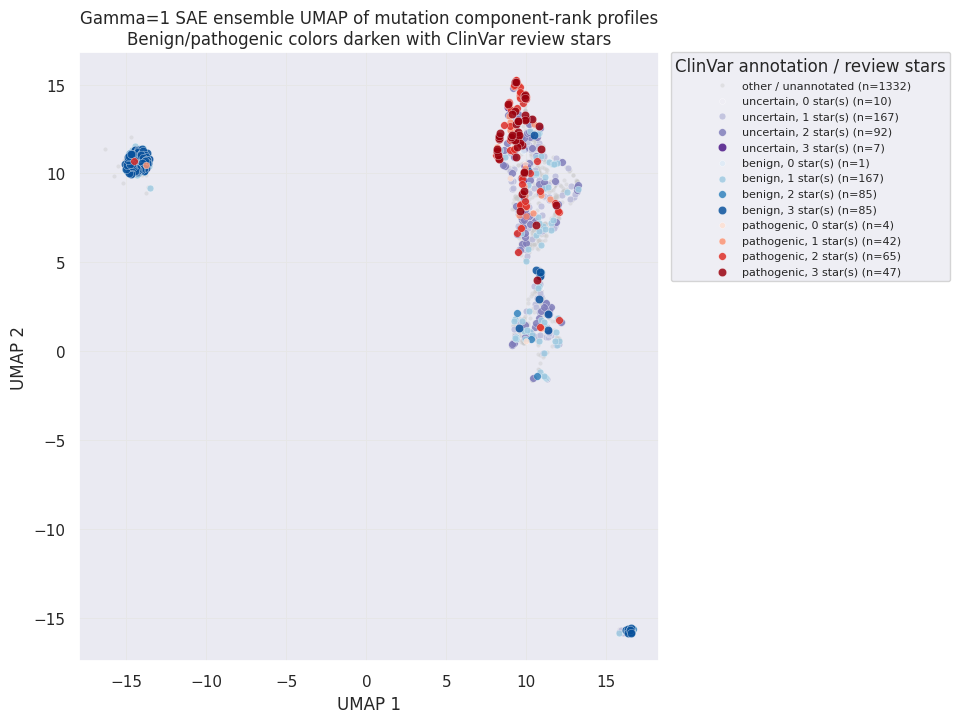

,annotation_plot,stars,n_mutations
0,benign,0,1
1,benign,1,167
2,benign,2,85
3,benign,3,85
4,other / unannotated,0,1099
5,other / unannotated,1,232
6,other / unannotated,3,1
7,pathogenic,0,4
8,pathogenic,1,42
9,pathogenic,2,65


Gamma=1 SAE ensemble UMAP coordinates: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/tables/BRCA1_best_sae_ensemble_gamma1_umap_component_ranks_by_clinvar.csv
Gamma=1 SAE ensemble UMAP figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/esm_data_analysis/BRCA1_plm_layer_sae/figures/BRCA1_best_sae_ensemble_gamma1_umap_component_ranks_by_clinvar.png


In [27]:
# UMAP of all mutations under the best gamma=1 SAE ensemble.
# The ensemble itself is rank-based, so the UMAP input is each mutation's 12-dimensional
# vector of gamma=1 component ranks before the final rank_worst aggregation.
if "overall_takeaway_specs" not in globals():
    raise RuntimeError("Run the Overall Takeaways preparation cell before this UMAP cell.")
if "per_sae_gamma_source_rows" not in globals() or "_per_sae_gamma_one_fitness" not in globals():
    raise RuntimeError("Run the per-SAE gamma setup and Overall Takeaways preparation cells before this UMAP cell.")
if "best_ensemble_row" not in globals():
    raise RuntimeError("Run the Overall Takeaways preparation cell so best_ensemble_row is defined.")

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache")
Path(os.environ["NUMBA_CACHE_DIR"]).mkdir(parents=True, exist_ok=True)

import umap
from sklearn.preprocessing import StandardScaler

component_series = []
for source_idx, source_row in per_sae_gamma_source_rows.reset_index(drop=True).iterrows():
    fitness_df = _per_sae_gamma_one_fitness(source_idx)
    component = f"{source_row['model_short']}_L{int(float(source_row['layer']))}"
    component_series.append(
        pd.Series(
            pd.to_numeric(fitness_df["fitness"], errors="coerce").to_numpy(dtype=float),
            index=fitness_df["SequenceIndex"].astype(str),
            name=component,
        )
    )

gamma1_component_score_matrix = pd.concat(component_series, axis=1)
gamma1_component_rank_matrix = gamma1_component_score_matrix.rank(method="average", ascending=True)
gamma1_component_rank_matrix = gamma1_component_rank_matrix.dropna(how="any")
if len(gamma1_component_rank_matrix) < 3:
    raise ValueError("Not enough mutations with complete gamma=1 component ranks for UMAP.")

gamma1_ensemble_fitness_df = h.rank_ensemble_fitness_from_score_matrix(
    gamma1_component_score_matrix,
    aggregation=str(best_ensemble_row["aggregation"]),
).set_index("SequenceIndex")

umap_input = StandardScaler().fit_transform(gamma1_component_rank_matrix.to_numpy(dtype=float))
n_neighbors = min(30, max(2, len(gamma1_component_rank_matrix) - 1))
gamma1_umap_embedding = umap.UMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    min_dist=0.12,
    metric="euclidean",
    random_state=42,
).fit_transform(umap_input)

gamma1_umap_df = pd.DataFrame(
    {
        "SequenceIndex": gamma1_component_rank_matrix.index.astype(str),
        "UMAP1": gamma1_umap_embedding[:, 0],
        "UMAP2": gamma1_umap_embedding[:, 1],
    }
)
gamma1_umap_df = gamma1_umap_df.merge(
    gamma1_ensemble_fitness_df[
        ["fitness", "selected_rank", "average_score", "n_component_model_layers"]
    ].rename(columns={"fitness": "ensemble_fitness_rank"}),
    left_on="SequenceIndex",
    right_index=True,
    how="left",
)

clinvar_umap_df = h.clinvar_annotation_table(
    paths.clinvar_annotation_cache_path,
    primary_key="hgvs_nt",
)[
    ["SequenceIndex", "annotation", "stars", "review_status", "clinvar_classification"]
].copy()
clinvar_umap_df["SequenceIndex"] = clinvar_umap_df["SequenceIndex"].astype(str)
clinvar_umap_df["stars"] = pd.to_numeric(clinvar_umap_df["stars"], errors="coerce").fillna(0).astype(int).clip(0, 3)
clinvar_umap_df = clinvar_umap_df.sort_values("stars", ascending=False).drop_duplicates("SequenceIndex")

gamma1_umap_df = gamma1_umap_df.merge(clinvar_umap_df, on="SequenceIndex", how="left")
gamma1_umap_df["annotation"] = gamma1_umap_df["annotation"].fillna("unannotated")
gamma1_umap_df["stars"] = pd.to_numeric(gamma1_umap_df["stars"], errors="coerce").fillna(0).astype(int).clip(0, 3)
gamma1_umap_df["annotation_plot"] = gamma1_umap_df["annotation"].replace(
    {"uncertain significance": "uncertain"}
)
gamma1_umap_df.loc[
    ~gamma1_umap_df["annotation_plot"].isin(["benign", "pathogenic", "uncertain"]),
    "annotation_plot",
] = "other / unannotated"

star_colors = {
    "benign": {0: "#deebf7", 1: "#9ecae1", 2: "#3182bd", 3: "#08519c"},
    "pathogenic": {0: "#fee0d2", 1: "#fc9272", 2: "#de2d26", 3: "#99000d"},
    "uncertain": {0: "#efedf5", 1: "#bcbddc", 2: "#807dba", 3: "#4a1486"},
}

fig, ax = plt.subplots(figsize=(9.8, 7.4))
background_df = gamma1_umap_df[gamma1_umap_df["annotation_plot"].eq("other / unannotated")]
if not background_df.empty:
    ax.scatter(
        background_df["UMAP1"],
        background_df["UMAP2"],
        s=9,
        color="0.78",
        alpha=0.38,
        linewidths=0,
        label=f"other / unannotated (n={len(background_df)})",
        zorder=1,
    )

for annotation in ["uncertain", "benign", "pathogenic"]:
    for stars in range(4):
        subset = gamma1_umap_df[
            gamma1_umap_df["annotation_plot"].eq(annotation)
            & gamma1_umap_df["stars"].eq(stars)
        ]
        if subset.empty:
            continue
        ax.scatter(
            subset["UMAP1"],
            subset["UMAP2"],
            s=18 + 6 * stars,
            color=star_colors[annotation][stars],
            alpha=0.84,
            edgecolors="white",
            linewidths=0.25,
            label=f"{annotation}, {stars} star(s) (n={len(subset)})",
            zorder=3 if annotation in {"benign", "pathogenic"} else 2,
        )

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title(
    "Gamma=1 SAE ensemble UMAP of mutation component-rank profiles\n"
    "Benign/pathogenic colors darken with ClinVar review stars"
)
ax.grid(color="0.90", linewidth=0.65)
ax.legend(
    title="ClinVar annotation / review stars",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0,
    fontsize=8,
)
fig.tight_layout()

gamma1_umap_coords_path = paths.table_dir / "BRCA1_best_sae_ensemble_gamma1_umap_component_ranks_by_clinvar.csv"
gamma1_umap_figure_path = paths.figure_dir / "BRCA1_best_sae_ensemble_gamma1_umap_component_ranks_by_clinvar.png"
gamma1_umap_df.to_csv(gamma1_umap_coords_path, index=False)
fig.savefig(gamma1_umap_figure_path, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

display(
    gamma1_umap_df.groupby(["annotation_plot", "stars"], dropna=False)
    .size()
    .rename("n_mutations")
    .reset_index()
    .sort_values(["annotation_plot", "stars"])
)
print(f"Gamma=1 SAE ensemble UMAP coordinates: {gamma1_umap_coords_path}")
print(f"Gamma=1 SAE ensemble UMAP figure: {gamma1_umap_figure_path}")
